# PRÁCTICA N.° 2 — Modelamiento del transporte y transformación de contaminantes

**Curso:** Modelamiento Ambiental  
**Unidad:** Fundamentos matemáticos del modelamiento ambiental  
**Tema:** Advección, difusión, dispersión y transformación de contaminantes

**Integrantes**

- Gonzales Barrios Diego Benny
- González Quiroz Yanira Lucero
- Llachi Vargas Claudia Milagros
- Palomino Gonzales Bianca Abigail
- Rodriguez Chavez Jason Edward

---

## Cómo usar este notebook

Este cuaderno resuelve **computacionalmente las Actividades 1 a 10** de la práctica y produce
todo el material que exige la **Actividad 12 (Producto final)**:

| Requisito de la Actividad 12 | Dónde está en este notebook |
|---|---|
| 56. Objetivos | Encabezado de cada actividad + sección 0 |
| 57. Fundamento teórico | Celda markdown "Fundamento" de cada actividad |
| 58. Desarrollo matemático | Celda markdown "Desarrollo matemático" de cada actividad |
| 59. Resolución de cada actividad | Celdas de código de las Actividades 1–10 |
| 60. Tablas de resultados | Todas las tablas se exportan a `resultados/*.csv` |
| 61. Gráficos | Todas las figuras se exportan a `figuras/*.png` |
| 62. Código o procedimiento computacional | Este mismo `.ipynb` |
| 63. Análisis de sensibilidad | Actividad 9 (incluye índices de sensibilidad y tornado) |
| 64. Discusión | Sección "Insumos numéricos para la Actividad 11" |
| 65. Conclusiones | Sección final de síntesis |

**Ejecutar todo:** `Kernel → Restart & Run All`. Al final se genera el archivo
`resultados/RESUMEN_RESULTADOS.md` con **todos los valores numéricos** de la práctica,
listo para pegarse en el informe o entregarse a otra herramienta de redacción.

> Convención de unidades: SI (m, s, mg). Cuando la constante $k$ está en h⁻¹ se convierte
> explícitamente la velocidad a km/h para mantener coherencia dimensional.

## 0. Configuración del entorno

Se importan las librerías, se fija un estilo gráfico único para todas las figuras
(paleta categórica de contraste validado, ejes y grilla recesivos) y se definen las
funciones auxiliares de **registro/exportación de tablas y figuras**.

In [1]:
# ============================================================================
# 0. CONFIGURACIÓN GENERAL
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
from IPython.display import display, Markdown

# ---- Carpetas de salida -----------------------------------------------------
FIG_DIR = Path("figuras");     FIG_DIR.mkdir(exist_ok=True)
RES_DIR = Path("resultados");  RES_DIR.mkdir(exist_ok=True)

# ---- Paleta categórica (orden fijo, no se recicla) --------------------------
COL = {
    "s1": "#2a78d6",  # azul
    "s2": "#eb6834",  # naranja
    "s3": "#1baf7a",  # aqua
    "s4": "#4a3aa7",  # violeta
    "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#8a8981",
    "grid": "#dcdbd6", "surf": "#ffffff",
}
SERIES = [COL["s1"], COL["s2"], COL["s3"], COL["s4"]]

plt.rcParams.update({
    "figure.figsize": (8.2, 4.6), "figure.dpi": 110, "savefig.dpi": 200,
    "figure.facecolor": COL["surf"], "axes.facecolor": COL["surf"],
    "savefig.facecolor": COL["surf"], "savefig.bbox": "tight",
    "axes.edgecolor": COL["grid"], "axes.linewidth": 1.0,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": COL["grid"], "grid.linewidth": 0.8, "grid.alpha": 0.7,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": COL["ink"], "axes.labelsize": 10.5, "axes.labelcolor": COL["ink2"],
    "xtick.color": COL["ink2"], "ytick.color": COL["ink2"],
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "lines.linewidth": 2.0, "lines.markersize": 6,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "font.size": 10.5, "axes.prop_cycle": plt.cycler(color=SERIES),
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# ---- Registro central de resultados -----------------------------------------
TABLAS = {}   # nombre -> (titulo, DataFrame)
FIGURAS = {}  # nombre -> ruta png
VALORES = {}  # clave  -> (valor, unidad, descripcion)

def tabla(df, nombre, titulo, mostrar=True):
    """Registra, exporta a CSV y muestra una tabla de resultados."""
    TABLAS[nombre] = (titulo, df.copy())
    df.to_csv(RES_DIR / f"{nombre}.csv", index=False, encoding="utf-8-sig")
    if mostrar:
        display(Markdown(f"**{titulo}**  ·  `resultados/{nombre}.csv`"))
        display(df.style.hide(axis="index").format(precision=4))
    return df

def guardar(fig, nombre):
    """Exporta una figura a PNG y la registra."""
    ruta = FIG_DIR / f"{nombre}.png"
    fig.savefig(ruta)
    FIGURAS[nombre] = str(ruta)
    return ruta

def anotar(clave, valor, unidad="", desc=""):
    """Registra un valor numérico clave para el resumen final."""
    VALORES[clave] = (valor, unidad, desc)
    return valor

def fmt(v, n=4):
    return f"{v:,.{n}f}" if isinstance(v, (int, float, np.floating)) else str(v)

print("Entorno listo.")
print(f"  numpy {np.__version__} | pandas {pd.__version__} | matplotlib {plt.matplotlib.__version__}")
print(f"  Figuras   -> {FIG_DIR.resolve()}")
print(f"  Resultados-> {RES_DIR.resolve()}")

Entorno listo.
  numpy 1.26.4 | pandas 2.1.4 | matplotlib 3.7.5
  Figuras   -> /home/jeremy/Documentos/modelamiento/figuras
  Resultados-> /home/jeremy/Documentos/modelamiento/resultados


In [2]:
# ============================================================================
# 0.1 MODELO GENERAL: funciones analíticas usadas en toda la práctica
# ============================================================================

def x_adveccion(t, u, x0=0.0):
    """Posición de la parcela bajo advección pura:  x = u t + x0   [m]"""
    return u * np.asarray(t, dtype=float) + x0

def c_difusion(x, t, M=1000.0, D=1e-9):
    """Pulso instantáneo con difusión pura (1D):
       C(x,t) = M / sqrt(4 pi D t) * exp(-x^2 / (4 D t))     [mg/m]"""
    x = np.asarray(x, dtype=float)
    return M / np.sqrt(4*np.pi*D*t) * np.exp(-x**2 / (4*D*t))

def c_primer_orden(t, C0=20.0, k=0.05):
    """Decaimiento de primer orden:  C = C0 exp(-k t)"""
    return C0 * np.exp(-k * np.asarray(t, dtype=float))

def c_adv_reac(x, C0=10.0, u=0.9, k=0.05):
    """Advección + transformación en estado estacionario: C(x) = C0 exp(-k x / u)
       Unidades coherentes: x [km], u [km/h], k [1/h]."""
    return C0 * np.exp(-k * np.asarray(x, dtype=float) / u)

def c_adv_disp(x, t, M=1000.0, u=0.25, Dx=50.0):
    """Advección + dispersión (pulso instantáneo):
       C(x,t) = M / sqrt(4 pi Dx t) * exp(-(x-u t)^2 / (4 Dx t))   [mg/m]"""
    x = np.asarray(x, dtype=float)
    return M / np.sqrt(4*np.pi*Dx*t) * np.exp(-(x - u*t)**2 / (4*Dx*t))

def c_integrado(x, t, M=1000.0, u=0.25, Dx=50.0, k_h=0.05):
    """Modelo integrado advección-dispersión-transformación.
       k_h en h^-1, t en s  ->  factor de decaimiento exp(-k_h * t/3600)."""
    return c_adv_disp(x, t, M, u, Dx) * np.exp(-k_h * t/3600.0)

def sigma_x(Dx, t):
    """Desviación estándar de la nube:  sigma = sqrt(2 Dx t)"""
    return np.sqrt(2.0 * Dx * t)

def c_max_pulso(M, Dcoef, t, k_h=0.0):
    """Concentración pico de un pulso gaussiano (con decaimiento opcional)."""
    return M / np.sqrt(4*np.pi*Dcoef*t) * np.exp(-k_h * t/3600.0)

def vida_media(k):
    """Vida media de una cinética de primer orden: t_1/2 = ln 2 / k"""
    return np.log(2.0) / k

def masa_numerica(x, c):
    """Masa total obtenida por integración numérica de la distribución (control)."""
    return np.trapz(c, x)

print("Funciones del modelo definidas: x_adveccion, c_difusion, c_primer_orden,")
print("c_adv_reac, c_adv_disp, c_integrado, sigma_x, c_max_pulso, vida_media, masa_numerica")

Funciones del modelo definidas: x_adveccion, c_difusion, c_primer_orden,
c_adv_reac, c_adv_disp, c_integrado, sigma_x, c_max_pulso, vida_media, masa_numerica


---
# ACTIVIDAD 1. TRANSPORTE ADVECTIVO

### 1.1 Objetivo
Comprender el transporte de un contaminante debido al movimiento del medio y resolver la
ecuación de advección para un sistema unidimensional.

### 1.2 Fundamento teórico
El transporte advectivo es el arrastre del contaminante por el propio movimiento del fluido.
La ecuación de advección unidimensional es

$$\frac{\partial C}{\partial t} + u\,\frac{\partial C}{\partial x} = 0,\qquad C = C(x,t)$$

### 1.3 Desarrollo matemático
Siguiendo una **parcela** de contaminante a lo largo de su trayectoria $x=x(t)$, la concentración
que experimenta es $C = C(x(t),t)$. Por la regla de la cadena (derivada material):

$$\frac{dC}{dt} = \frac{\partial C}{\partial t} + \frac{\partial C}{\partial x}\frac{dx}{dt}
\quad\text{y con}\quad \frac{dx}{dt} = u \;\Rightarrow\;
\frac{dC}{dt} = \frac{\partial C}{\partial t} + u\frac{\partial C}{\partial x} = 0$$

Es decir, **a lo largo de la trayectoria de la parcela la concentración es constante**:
$C = C_0$. La trayectoria se obtiene integrando $dx/dt = u$:

$$x = u\,t + x_0 \;\;\xrightarrow{\;x_0=0\;}\;\; \boxed{x = u\,t}$$

Las rectas $x = ut + x_0$ son las **características** de la ecuación: sobre ellas la solución se
propaga sin deformarse, $C(x,t) = C_0(x-ut)$.

### 1.5 Ejercicio
$u = 0{,}25\ \mathrm{m/s}$, $C_0 = 10\ \mathrm{mg/L}$.

In [3]:
# ============================================================================
# ACTIVIDAD 1 — Ejercicio 1.5 (preguntas 1 a 5)
# ============================================================================
u_a1  = 0.25    # m/s
C0_a1 = 10.0    # mg/L

t_30min = 30*60          # s
t_2h    = 2*3600         # s
d_5km   = 5000.0         # m

x_30min = x_adveccion(t_30min, u_a1)
x_2h    = x_adveccion(t_2h,    u_a1)
t_5km   = d_5km / u_a1
C_5km   = C0_a1          # advección pura: la concentración no cambia

a1 = pd.DataFrame([
    ["1. Distancia a los 30 min", "x = u·t = 0.25 · 1800",        x_30min,      "m"],
    ["2. Distancia a las 2 h",    "x = u·t = 0.25 · 7200",        x_2h,         "m"],
    ["3. Tiempo para 5 km",       "t = x/u = 5000 / 0.25",        t_5km,        "s"],
    ["3b. Tiempo para 5 km",      "t / 3600",                     t_5km/3600,   "h"],
    ["4. Concentración a 5 km",   "C = C0 (advección pura)",      C_5km,        "mg/L"],
], columns=["Pregunta", "Expresión", "Resultado", "Unidad"])

tabla(a1, "act1_ejercicio", "Tabla 1.1 — Resultados del ejercicio de advección (u = 0.25 m/s)")

anotar("A1_x_30min", x_30min, "m", "Distancia recorrida en 30 min con u=0.25 m/s")
anotar("A1_x_2h",    x_2h,    "m", "Distancia recorrida en 2 h con u=0.25 m/s")
anotar("A1_t_5km_s", t_5km,   "s", "Tiempo para recorrer 5 km")
anotar("A1_t_5km_h", t_5km/3600, "h", "Tiempo para recorrer 5 km")
anotar("A1_C_5km",   C_5km,   "mg/L", "Concentración tras 5 km (advección pura)")

print(f"5. La concentración se mantiene en {C_5km:.1f} mg/L: en advección pura dC/dt = 0 a lo")
print("   largo de la trayectoria; el flujo solo traslada el centro de masa, no lo diluye")
print("   ni lo degrada (no hay dispersión ni reacción en el modelo).")

**Tabla 1.1 — Resultados del ejercicio de advección (u = 0.25 m/s)**  ·  `resultados/act1_ejercicio.csv`

Pregunta,Expresión,Resultado,Unidad
1. Distancia a los 30 min,x = u·t = 0.25 · 1800,450.0000,m
2. Distancia a las 2 h,x = u·t = 0.25 · 7200,1800.0000,m
3. Tiempo para 5 km,t = x/u = 5000 / 0.25,20000.0000,s
3b. Tiempo para 5 km,t / 3600,5.5556,h
4. Concentración a 5 km,C = C0 (advección pura),10.0000,mg/L


5. La concentración se mantiene en 10.0 mg/L: en advección pura dC/dt = 0 a lo
   largo de la trayectoria; el flujo solo traslada el centro de masa, no lo diluye
   ni lo degrada (no hay dispersión ni reacción en el modelo).


**Tabla 1.2 — Distancia recorrida x = u·t para tres velocidades (0–10 h)**  ·  `resultados/act1_x_vs_t.csv`

t (h),x (m) | u=0.10 m/s,x (m) | u=0.25 m/s,x (m) | u=0.50 m/s,x (km) | u=0.25
0,0.0000,0.0000,0.0000,0.0000
1,360.0000,900.0000,1800.0000,0.9000
2,720.0000,1800.0000,3600.0000,1.8000
3,1080.0000,2700.0000,5400.0000,2.7000
4,1440.0000,3600.0000,7200.0000,3.6000
5,1800.0000,4500.0000,9000.0000,4.5000
6,2160.0000,5400.0000,10800.0000,5.4000
7,2520.0000,6300.0000,12600.0000,6.3000
8,2880.0000,7200.0000,14400.0000,7.2000
9,3240.0000,8100.0000,16200.0000,8.1000


Comprobación de la pendiente dx/dt (ajuste lineal) frente a u:
  u = 0.10 m/s  ->  pendiente ajustada = 0.1000 m/s   (error = 2.78e-17)
  u = 0.25 m/s  ->  pendiente ajustada = 0.2500 m/s   (error = 2.78e-17)
  u = 0.50 m/s  ->  pendiente ajustada = 0.5000 m/s   (error = 5.55e-17)


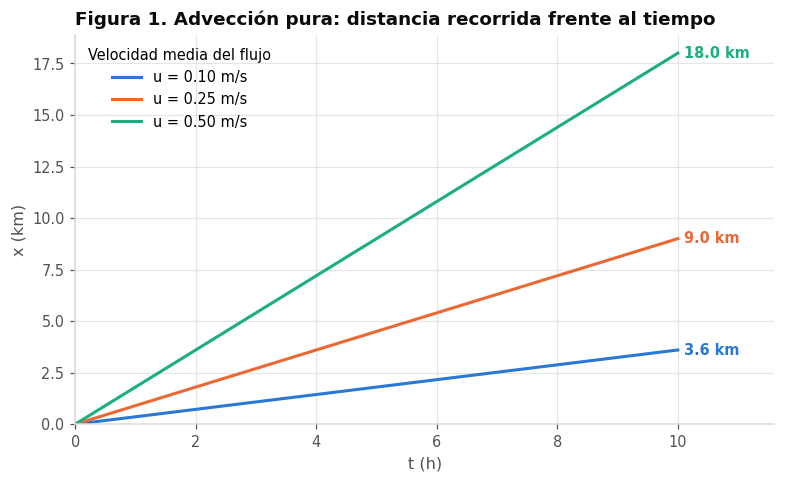

In [4]:
# ============================================================================
# ACTIVIDAD 1 — 1.6 Actividad computacional: x vs t para 0 <= t <= 10 h
# ============================================================================
velocidades = [0.10, 0.25, 0.50]                 # m/s
t_h  = np.arange(0, 10.001, 0.5)                 # h
t_s  = t_h * 3600.0

# --- Tabla (cada hora entera) ---
t_tab = np.arange(0, 11, 1)
a1c = pd.DataFrame({"t (h)": t_tab})
for u in velocidades:
    a1c[f"x (m) | u={u:.2f} m/s"] = x_adveccion(t_tab*3600.0, u)
a1c["x (km) | u=0.25"] = a1c["x (m) | u=0.25 m/s"]/1000.0
tabla(a1c, "act1_x_vs_t", "Tabla 1.2 — Distancia recorrida x = u·t para tres velocidades (0–10 h)")

# --- Pendiente numérica: comprobación de que la pendiente es u ---
pend = {u: np.polyfit(t_s, x_adveccion(t_s, u), 1)[0] for u in velocidades}
print("Comprobación de la pendiente dx/dt (ajuste lineal) frente a u:")
for u, p in pend.items():
    print(f"  u = {u:.2f} m/s  ->  pendiente ajustada = {p:.4f} m/s   (error = {abs(p-u):.2e})")

# --- Gráfica ---
fig, ax = plt.subplots()
for u, c in zip(velocidades, SERIES):
    x = x_adveccion(t_s, u)/1000.0
    ax.plot(t_h, x, color=c, label=f"u = {u:.2f} m/s")
    ax.annotate(f"{x[-1]:.1f} km", xy=(t_h[-1], x[-1]), xytext=(4, 0),
                textcoords="offset points", color=c, fontsize=9.5, va="center", fontweight="bold")
ax.set_title("Figura 1. Advección pura: distancia recorrida frente al tiempo")
ax.set_xlabel("t (h)"); ax.set_ylabel("x (km)")
ax.set_xlim(0, 11.6); ax.set_ylim(bottom=0)
ax.legend(title="Velocidad media del flujo", title_fontsize=9.5, loc="upper left")
guardar(fig, "fig01_adveccion_x_vs_t"); plt.show()

### 1.6 Respuestas a las preguntas 6, 7 y 8

**6. ¿Qué ocurre con la distancia recorrida cuando aumenta $u$?**  
La relación $x=ut$ es lineal y directamente proporcional: para un mismo tiempo, duplicar la
velocidad duplica la distancia recorrida. En la Figura 1, a $t=10\ \mathrm{h}$ se recorren
3,6 km con $u=0{,}10$ m/s; 9,0 km con $u=0{,}25$ m/s y 18,0 km con $u=0{,}50$ m/s. El
contaminante llega antes a los puntos de interés (captaciones, zonas sensibles), por lo que
**aumentar $u$ reduce el tiempo de respuesta disponible**.

**7. ¿Qué representa físicamente la pendiente de la gráfica?**  
La pendiente es $dx/dt = u$, es decir, **la velocidad media del flujo**: la celeridad con que
se desplaza el centro de masa de la parcela. La comprobación numérica del ajuste lineal
reproduce exactamente los valores de $u$ (error del orden de $10^{-16}$).

**8. ¿Qué supuesto permite utilizar $x=ut$?**  
Se requiere que $u$ sea **constante** (en el tiempo y en el espacio): flujo unidimensional,
uniforme y permanente, sin aceleración ni variaciones de sección, y que la parcela se mueva
exactamente con el fluido (no hay deslizamiento, sedimentación ni retardo). Además, con
$x_0 = 0$ se está fijando el origen en el punto de vertido en $t=0$.

---
# ACTIVIDAD 2. DIFUSIÓN MOLECULAR

### 2.1 Objetivo
Comprender el movimiento de un contaminante causado por gradientes de concentración y analizar
el efecto del coeficiente de difusión.

### 2.2 Fundamento teórico
La primera ley de Fick establece que el flujo difusivo es proporcional y opuesto al gradiente
de concentración, $J = -D\,\partial C/\partial x$. Sustituyéndola en el balance de masa se
obtiene la segunda ley de Fick (ecuación de difusión):

$$\frac{\partial C}{\partial t} = D\,\frac{\partial^2 C}{\partial x^2},\qquad [D] = \frac{L^2}{T}$$

### 2.3 Desarrollo matemático — solución para una liberación instantánea
Para una masa $M$ liberada instantáneamente en $x=0$ (fuente puntual, medio infinito) la
solución es una **gaussiana que se ensancha en el tiempo**:

$$C(x,t) = \frac{M}{\sqrt{4\pi D t}}\;\exp\!\left(-\frac{x^{2}}{4Dt}\right)$$

De ella se derivan las dos propiedades que se analizan:

$$C_{\max}(t) = \frac{M}{\sqrt{4\pi D t}} \propto t^{-1/2}
\qquad\text{y}\qquad
\sigma_x(t) = \sqrt{2Dt} \propto t^{1/2}$$

El área bajo la curva se conserva: $\int_{-\infty}^{\infty} C\,dx = M$ (no hay pérdida de masa,
solo redistribución).

### 2.4 Ejercicio
$M = 1000\ \mathrm{mg}$, $D = 1\times10^{-9}\ \mathrm{m^2/s}$; se evalúa a 1 h, 6 h y 24 h.

In [5]:
# ============================================================================
# ACTIVIDAD 2 — Difusión molecular: M = 1000 mg, D = 1e-9 m^2/s
# ============================================================================
M_a2 = 1000.0     # mg
D_a2 = 1e-9       # m^2/s
tiempos_a2 = {"1 h": 3600.0, "6 h": 21600.0, "24 h": 86400.0}

filas = []
for etiq, t in tiempos_a2.items():
    s   = sigma_x(D_a2, t)                 # m
    cmx = c_max_pulso(M_a2, D_a2, t)       # mg/m
    filas.append([etiq, t, cmx, s, s*1000, 4*s*1000])
a2 = pd.DataFrame(filas, columns=[
    "Tiempo", "t (s)", "C_max (mg/m)", "sigma_x (m)", "sigma_x (mm)", "Ancho ±2σ (mm)"])
tabla(a2, "act2_difusion_resumen",
      "Tabla 2.1 — Difusión molecular: pico y ensanchamiento de la nube")

for etiq, t in tiempos_a2.items():
    anotar(f"A2_sigma_{etiq.replace(' ','')}", sigma_x(D_a2, t)*1000, "mm", f"sigma_x a {etiq} (D=1e-9)")
    anotar(f"A2_Cmax_{etiq.replace(' ','')}", c_max_pulso(M_a2, D_a2, t), "mg/m", f"C_max a {etiq} (D=1e-9)")

# --- Distribución espacial C(x) en puntos seleccionados ---
x_mm = np.array([0.0, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0])     # mm
a2b = pd.DataFrame({"x (mm)": x_mm})
for etiq, t in tiempos_a2.items():
    a2b[f"C (mg/m) | t={etiq}"] = c_difusion(x_mm/1000.0, t, M_a2, D_a2)
tabla(a2b, "act2_perfil_C", "Tabla 2.2 — Distribución espacial C(x) a 1 h, 6 h y 24 h")

# --- Control de masa (la difusión conserva la masa) ---
xx = np.linspace(-0.05, 0.05, 200001)
print("Control de conservación de masa (integración numérica de C(x)):")
for etiq, t in tiempos_a2.items():
    print(f"  t = {etiq:>4}: M_numérica = {masa_numerica(xx, c_difusion(xx, t, M_a2, D_a2)):.3f} mg   (M teórica = 1000 mg)")

**Tabla 2.1 — Difusión molecular: pico y ensanchamiento de la nube**  ·  `resultados/act2_difusion_resumen.csv`

Tiempo,t (s),C_max (mg/m),sigma_x (m),sigma_x (mm),Ancho ±2σ (mm)
1 h,3600.0000,148677.0097,0.0027,2.6833,10.7331
6 h,21600.0000,60697.1350,0.0066,6.5727,26.2907
24 h,86400.0000,30348.5675,0.0131,13.1453,52.5814


**Tabla 2.2 — Distribución espacial C(x) a 1 h, 6 h y 24 h**  ·  `resultados/act2_perfil_C.csv`

x (mm),C (mg/m) | t=1 h,C (mg/m) | t=6 h,C (mg/m) | t=24 h
0.0000,148677.0097,60697.1350,30348.5675
1.0000,138702.5606,59998.6717,30260.8803
2.0000,112617.6502,57951.1377,29999.3359
3.0000,79581.0686,54692.6774,29568.4422
5.0000,26197.5297,45446.9016,28230.7372
8.0000,1746.0076,28938.0043,25218.1540
12.0000,6.7499,11464.2080,20007.0088


Control de conservación de masa (integración numérica de C(x)):
  t =  1 h: M_numérica = 1000.000 mg   (M teórica = 1000 mg)
  t =  6 h: M_numérica = 1000.000 mg   (M teórica = 1000 mg)
  t = 24 h: M_numérica = 999.857 mg   (M teórica = 1000 mg)


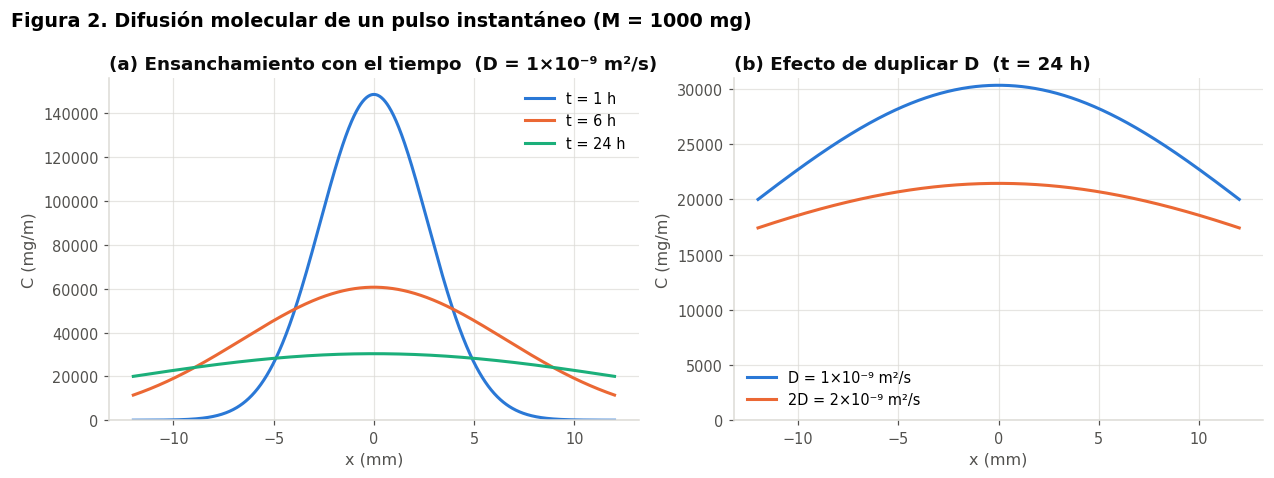

**Tabla 2.3 — Efecto de duplicar D a t = 24 h**  ·  `resultados/act2_duplicar_D.csv`

Caso,D (m²/s),C_max (mg/m),sigma_x (mm),Razón C_max,Razón sigma
D,0.0000,30348.5675,13.1453,1.0000,1.0000
2D,0.0000,21459.6779,18.5903,0.7071,1.4142



1/sqrt(2) = 0.7071   sqrt(2) = 1.4142  -> el pico cae y el ancho crece en esos factores.


**Tabla 2.4 — Tiempo necesario para alcanzar σ = 100 m según el mecanismo**  ·  `resultados/act2_difusion_vs_dispersion.csv`

Proceso,Coeficiente (m²/s),t para σ = 100 m (s),t (años)
Difusión molecular,0.0000,5000000000000.0000,158440.4391
Dispersión longitudinal,50.0000,100.0000,0.0000



Razón Dx/D = 5.000e+10  ->  la dispersión en un río es ~5×10^10 veces más eficaz.


In [6]:
# ============================================================================
# ACTIVIDAD 2 — Gráfica de la distribución y efecto de duplicar D
# ============================================================================
x_plot_mm = np.linspace(-12, 12, 801)
x_plot    = x_plot_mm / 1000.0

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))

# (a) Evolución temporal
ax = axes[0]
for (etiq, t), c in zip(tiempos_a2.items(), SERIES):
    ax.plot(x_plot_mm, c_difusion(x_plot, t, M_a2, D_a2), color=c, label=f"t = {etiq}")
ax.set_title("(a) Ensanchamiento con el tiempo  (D = 1×10⁻⁹ m²/s)")
ax.set_xlabel("x (mm)"); ax.set_ylabel("C (mg/m)")
ax.legend(); ax.set_ylim(bottom=0)

# (b) Efecto de duplicar D a t = 24 h
ax = axes[1]
t24 = 86400.0
for D, c, lab in [(D_a2, SERIES[0], "D = 1×10⁻⁹ m²/s"),
                  (2*D_a2, SERIES[1], "2D = 2×10⁻⁹ m²/s")]:
    ax.plot(x_plot_mm, c_difusion(x_plot, t24, M_a2, D), color=c, label=lab)
ax.set_title("(b) Efecto de duplicar D  (t = 24 h)")
ax.set_xlabel("x (mm)"); ax.set_ylabel("C (mg/m)")
ax.legend(); ax.set_ylim(bottom=0)

fig.suptitle("Figura 2. Difusión molecular de un pulso instantáneo (M = 1000 mg)",
             fontsize=12.5, fontweight="bold", x=0.005, ha="left")
fig.tight_layout()
guardar(fig, "fig02_difusion_molecular"); plt.show()

# --- Cuantificación del efecto de duplicar D ---
cmp_D = pd.DataFrame([
    ["D",  D_a2,   c_max_pulso(M_a2, D_a2, t24),   sigma_x(D_a2, t24)*1000],
    ["2D", 2*D_a2, c_max_pulso(M_a2, 2*D_a2, t24), sigma_x(2*D_a2, t24)*1000],
], columns=["Caso", "D (m²/s)", "C_max (mg/m)", "sigma_x (mm)"])
cmp_D["Razón C_max"]  = cmp_D["C_max (mg/m)"] / cmp_D["C_max (mg/m)"].iloc[0]
cmp_D["Razón sigma"]  = cmp_D["sigma_x (mm)"] / cmp_D["sigma_x (mm)"].iloc[0]
tabla(cmp_D, "act2_duplicar_D", "Tabla 2.3 — Efecto de duplicar D a t = 24 h")
print(f"\n1/sqrt(2) = {1/np.sqrt(2):.4f}   sqrt(2) = {np.sqrt(2):.4f}  -> el pico cae y el ancho crece en esos factores.")

# --- Comparación difusión molecular vs dispersión en un río ---
sigma_obj = 100.0                      # m
t_D  = sigma_obj**2 / (2*D_a2)         # s con difusión molecular
t_Dx = sigma_obj**2 / (2*50.0)         # s con dispersión longitudinal Dx = 50 m^2/s
comp = pd.DataFrame([
    ["Difusión molecular", D_a2, t_D, t_D/(3600*24*365.25)],
    ["Dispersión longitudinal", 50.0, t_Dx, t_Dx/(3600*24*365.25)],
], columns=["Proceso", "Coeficiente (m²/s)", "t para σ = 100 m (s)", "t (años)"])
tabla(comp, "act2_difusion_vs_dispersion",
      "Tabla 2.4 — Tiempo necesario para alcanzar σ = 100 m según el mecanismo")
anotar("A2_razon_Dx_D", 50.0/D_a2, "-", "Razón Dx/D entre dispersión longitudinal y difusión molecular")
print(f"\nRazón Dx/D = {50.0/D_a2:.3e}  ->  la dispersión en un río es ~5×10^10 veces más eficaz.")

### 2.5 Respuestas a las preguntas 9 a 13

**9. ¿Qué ocurre con la concentración máxima cuando aumenta el tiempo?**  
Disminuye según $C_{\max}\propto t^{-1/2}$. Entre 1 h y 24 h el tiempo se multiplica por 24 y el
pico se reduce en un factor $\sqrt{24}\approx 4{,}9$ (de ≈1,49×10⁵ a ≈3,03×10⁴ mg/m). La caída
no es proporcional al tiempo, sino a su raíz cuadrada.

**10. ¿Qué ocurre con la extensión espacial de la distribución?**  
Aumenta como $\sigma_x=\sqrt{2Dt}\propto t^{1/2}$: la nube se ensancha continuamente
(≈2,68 mm a 1 h; ≈6,57 mm a 6 h; ≈13,1 mm a 24 h). El área bajo la curva se mantiene igual a
$M$ —la comprobación numérica devuelve 1000 mg en los tres tiempos—, de modo que **la masa se
conserva y solo se redistribuye**.

**11. ¿Qué ocurre si se duplica $D$?**  
El proceso se acelera: $\sigma_x$ crece por $\sqrt{2}\approx1{,}414$ y el pico cae por
$1/\sqrt{2}\approx0{,}707$ (Tabla 2.3). Equivale a "adelantar el reloj": duplicar $D$ produce a
tiempo $t$ el mismo perfil que $D$ produciría en $2t$.

**12. ¿Qué ocurriría si $D=0$?**  
Desaparece el término difusivo y $\partial C/\partial t = 0$: no hay ensanchamiento y la masa
permanece indefinidamente donde fue liberada (una delta de Dirac). Matemáticamente la solución
gaussiana se vuelve singular ($\sigma_x\to0$, $C_{\max}\to\infty$), lo que refleja la
idealización de una fuente puntual sin ningún mecanismo de mezcla.

**13. ¿Por qué la difusión molecular suele ser mucho menor que la dispersión en un río?**  
Porque son mecanismos distintos. La difusión molecular ($D\sim10^{-9}$ m²/s) obedece solo a la
agitación térmica de las moléculas, mientras que la dispersión longitudinal
($D_x\sim10$–$10^{3}$ m²/s) resulta de la **advección diferencial**: el perfil de velocidades
(más rápido en el centro y en superficie, más lento en las orillas y el fondo) combinado con la
mezcla turbulenta transversal estira la nube. La Tabla 2.4 lo cuantifica: alcanzar $\sigma=100$ m
tomaría ≈158 000 años por difusión molecular y solo ≈28 h por dispersión, una razón
$D_x/D\approx5\times10^{10}$. Por eso en ríos la difusión molecular se desprecia.

---
# ACTIVIDAD 3. ESTIMACIÓN DEL COEFICIENTE DE DISPERSIÓN

### 3.1 Objetivo
Estimar el coeficiente de dispersión longitudinal a partir de la distribución espacial de un
trazador.

### 3.2 Fundamento y desarrollo matemático
Para un pulso que se dispersa según la ecuación de difusión-dispersión, el **segundo momento
central** de la distribución crece linealmente con el tiempo (relación de Einstein):

$$\sigma_x^{2} = 2\,D_x\,t \qquad\Longrightarrow\qquad D_x = \frac{\sigma_x^{2}}{2t}$$

Esto sugiere dos formas de estimación:
1. **Puntual:** aplicar $D_x=\sigma_x^2/(2t)$ a cada observación por separado.
2. **Por regresión:** ajustar una recta $\sigma_x^2$ vs. $t$ **forzada por el origen**; su
   pendiente es $2D_x$, lo que aprovecha las tres mediciones simultáneamente.

### 3.3 Datos del trazador
| Tiempo (s) | $\sigma_x$ (m) |
|---|---|
| 1800 | 400 |
| 3600 | 600 |
| 5400 | 800 |

In [7]:
# ============================================================================
# ACTIVIDAD 3 — Estimación de Dx (procedimiento 14 a 17)
# ============================================================================
t_a3     = np.array([1800.0, 3600.0, 5400.0])   # s
sigma_a3 = np.array([400.0,  600.0,  800.0])    # m

# 14-16: elevar al cuadrado, tiempo en segundos, aplicar Dx = sigma^2/(2t)
sig2  = sigma_a3**2
Dx_pt = sig2 / (2*t_a3)

a3 = pd.DataFrame({
    "t (s)": t_a3,
    "t (min)": t_a3/60,
    "sigma_x (m)": sigma_a3,
    "sigma_x² (m²)": sig2,
    "Dx = σ²/(2t) (m²/s)": Dx_pt,
})
a3["Desv. respecto a la media (%)"] = 100*(Dx_pt - Dx_pt.mean())/Dx_pt.mean()
tabla(a3, "act3_estimacion_Dx", "Tabla 3.1 — Estimación puntual del coeficiente de dispersión longitudinal")

# 17: comparación y ajuste global por regresión forzada al origen
pend_origen = np.sum(t_a3*sig2) / np.sum(t_a3**2)     # sigma^2 = pendiente * t
Dx_reg      = pend_origen / 2
pend_libre, inter_libre = np.polyfit(t_a3, sig2, 1)
r2 = 1 - np.sum((sig2 - (pend_libre*t_a3 + inter_libre))**2)/np.sum((sig2 - sig2.mean())**2)

resumen_a3 = pd.DataFrame([
    ["Media de las estimaciones puntuales", Dx_pt.mean()],
    ["Mediana de las estimaciones puntuales", np.median(Dx_pt)],
    ["Desviación estándar", Dx_pt.std(ddof=1)],
    ["Coeficiente de variación (%)", 100*Dx_pt.std(ddof=1)/Dx_pt.mean()],
    ["Dx por regresión forzada al origen", Dx_reg],
    ["Dx por regresión libre (pendiente/2)", pend_libre/2],
    ["Ordenada al origen de la regresión libre (m²)", inter_libre],
    ["R² de la regresión libre", r2],
    ["Rango (mín – máx) de Dx", Dx_pt.max()-Dx_pt.min()],
], columns=["Indicador", "Valor"])
tabla(resumen_a3, "act3_resumen_Dx", "Tabla 3.2 — Comparación de las estimaciones de Dx (m²/s)")

anotar("A3_Dx_1800", Dx_pt[0], "m²/s", "Dx estimado a t=1800 s")
anotar("A3_Dx_3600", Dx_pt[1], "m²/s", "Dx estimado a t=3600 s")
anotar("A3_Dx_5400", Dx_pt[2], "m²/s", "Dx estimado a t=5400 s")
anotar("A3_Dx_medio", Dx_pt.mean(), "m²/s", "Dx medio de las tres observaciones")
anotar("A3_Dx_regresion", Dx_reg, "m²/s", "Dx por regresión de sigma² vs t forzada al origen")
anotar("A3_CV_Dx", 100*Dx_pt.std(ddof=1)/Dx_pt.mean(), "%", "Coeficiente de variación de Dx")

print(f"Dx varía entre {Dx_pt.min():.2f} y {Dx_pt.max():.2f} m²/s  (CV = {100*Dx_pt.std(ddof=1)/Dx_pt.mean():.1f} %)")
print(f"Tendencia: Dx CRECE con el tiempo -> comportamiento no fickiano en la fase inicial.")

**Tabla 3.1 — Estimación puntual del coeficiente de dispersión longitudinal**  ·  `resultados/act3_estimacion_Dx.csv`

t (s),t (min),sigma_x (m),sigma_x² (m²),Dx = σ²/(2t) (m²/s),Desv. respecto a la media (%)
1800.0000,30.0000,400.0000,160000.0000,44.4444,-13.2530
3600.0000,60.0000,600.0000,360000.0000,50.0000,-2.4096
5400.0000,90.0000,800.0000,640000.0000,59.2593,15.6627


**Tabla 3.2 — Comparación de las estimaciones de Dx (m²/s)**  ·  `resultados/act3_resumen_Dx.csv`

Indicador,Valor
Media de las estimaciones puntuales,51.2346
Mediana de las estimaciones puntuales,50.0000
Desviación estándar,7.4842
Coeficiente de variación (%),14.6077
Dx por regresión forzada al origen,55.5556
Dx por regresión libre (pendiente/2),66.6667
Ordenada al origen de la regresión libre (m²),-93333.3333
R² de la regresión libre,0.9908
Rango (mín – máx) de Dx,14.8148


Dx varía entre 44.44 y 59.26 m²/s  (CV = 14.6 %)
Tendencia: Dx CRECE con el tiempo -> comportamiento no fickiano en la fase inicial.


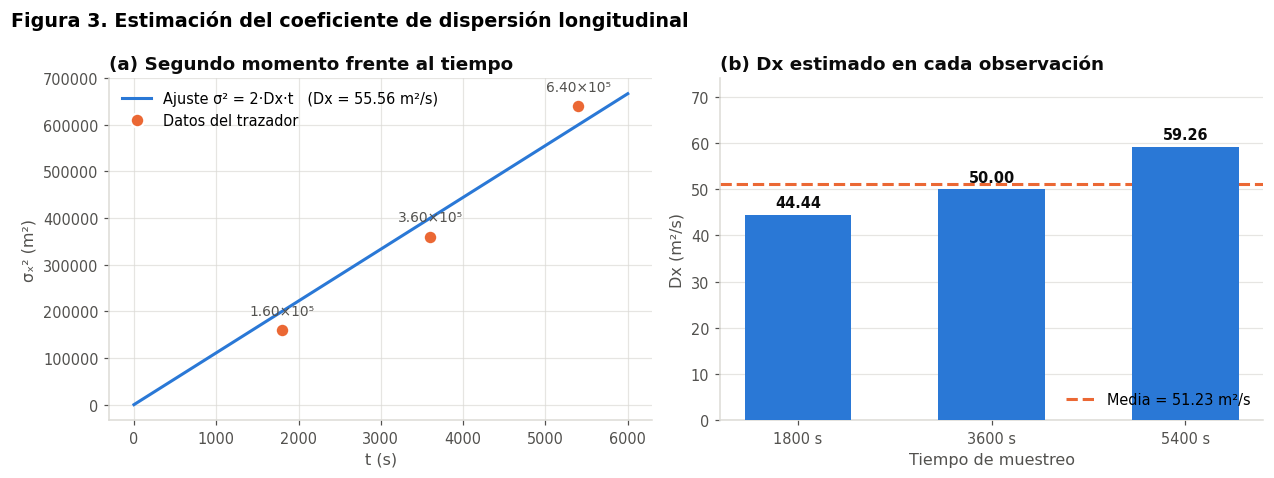

In [8]:
# ============================================================================
# ACTIVIDAD 3 — Gráficas de verificación del modelo sigma² = 2 Dx t
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))

# (a) sigma^2 vs t con la recta ajustada
ax = axes[0]
t_line = np.linspace(0, 6000, 200)
ax.plot(t_line, pend_origen*t_line, color=COL["s1"],
        label=f"Ajuste σ² = 2·Dx·t   (Dx = {Dx_reg:.2f} m²/s)")
ax.plot(t_a3, sig2, "o", color=COL["s2"], markersize=9, zorder=3,
        markeredgecolor="white", markeredgewidth=1.5, label="Datos del trazador")
for ti, si in zip(t_a3, sig2):
    ax.annotate(f"{si/1e5:.2f}×10⁵", xy=(ti, si), xytext=(0, 10),
                textcoords="offset points", ha="center", fontsize=9, color=COL["ink2"])
ax.set_title("(a) Segundo momento frente al tiempo")
ax.set_xlabel("t (s)"); ax.set_ylabel("σₓ² (m²)")
ax.legend(loc="upper left")

# (b) Dx puntual por observación
ax = axes[1]
ax.bar([f"{int(t)} s" for t in t_a3], Dx_pt, color=COL["s1"], width=0.55, zorder=3)
ax.axhline(Dx_pt.mean(), color=COL["s2"], linestyle="--", linewidth=2,
           label=f"Media = {Dx_pt.mean():.2f} m²/s")
for i, v in enumerate(Dx_pt):
    ax.annotate(f"{v:.2f}", xy=(i, v), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=9.5, color=COL["ink"], fontweight="bold")
ax.set_title("(b) Dx estimado en cada observación")
ax.set_xlabel("Tiempo de muestreo"); ax.set_ylabel("Dx (m²/s)")
ax.set_ylim(0, Dx_pt.max()*1.25); ax.legend(loc="lower right")
ax.grid(axis="x", visible=False)

fig.suptitle("Figura 3. Estimación del coeficiente de dispersión longitudinal",
             fontsize=12.5, fontweight="bold", x=0.005, ha="left")
fig.tight_layout()
guardar(fig, "fig03_estimacion_Dx"); plt.show()

### 3.5 Respuestas a las preguntas 18 a 21

**18. ¿El valor de $D_x$ es constante?**  
No. Las tres observaciones dan 44,44; 50,00 y 59,26 m²/s (media 51,23 m²/s, CV ≈ 14,6 %) y
muestran una **tendencia creciente con el tiempo**. Si el proceso fuera estrictamente fickiano,
los tres valores coincidirían. El crecimiento indica que la nube aún se encuentra en la
**fase inicial (no fickiana)**, en la que el trazador todavía no se ha mezclado por completo en
la sección transversal y $\sigma_x^2$ crece más rápido que linealmente.

**19. ¿Qué supuestos son necesarios para considerar $D_x$ constante?**  
- Flujo permanente y uniforme, con sección, pendiente y rugosidad aproximadamente constantes.  
- Mezcla transversal y vertical completa (fase fickiana de Taylor, alcanzada tras una distancia
  del orden de $L\approx 0{,}4\,u\,B^2/\varepsilon_y$ desde el vertido).  
- Contaminante conservativo y no reactivo, sin intercambio con zonas muertas, sedimentos ni
  vegetación de ribera.  
- Ausencia de aportes o extracciones laterales de agua o de masa.

**20. ¿Por qué $D_x$ puede ser mucho mayor que $D$?**  
Porque $D_x$ no es un coeficiente molecular sino un **coeficiente efectivo** que agrupa el efecto
del cizallamiento del perfil de velocidades (dispersión de Taylor) más la turbulencia. Aquí
$D_x\approx51$ m²/s frente a $D=10^{-9}$ m²/s: una razón de ~5×10¹⁰.

**21. ¿Qué información de campo sería necesaria para obtener un valor realista?**  
Curvas completas de paso del trazador (concentración vs. tiempo) en **varias secciones aguas
abajo**, con las que calcular los momentos temporales; geometría del cauce (ancho $B$,
profundidad media $h$, área); velocidad media y de corte $u^*$ (pendiente $S$); caudal;
rugosidad; y registro de zonas de almacenamiento temporal. Con ello puede aplicarse el método de
los momentos o el de ruta-tiempo entre dos secciones, que evita la incertidumbre de la condición
inicial.

---
# ACTIVIDAD 4. TRANSFORMACIÓN DE PRIMER ORDEN

### 4.1 Objetivo
Determinar la evolución temporal de la concentración de un contaminante sometido a una reacción
de primer orden.

### 4.2 Desarrollo matemático
Una cinética de primer orden supone que la velocidad de pérdida es proporcional a la
concentración presente:

$$\frac{dC}{dt} = -kC \;\Longrightarrow\; \frac{dC}{C} = -k\,dt
\;\Longrightarrow\; \ln C = -kt + A$$

Con la condición inicial $C(0)=C_0$ resulta $A=\ln C_0$ y por lo tanto

$$\boxed{C(t) = C_0\,e^{-kt}}$$

La representación $\ln C$ vs. $t$ es una recta de pendiente $-k$: ése es el criterio gráfico para
verificar que una cinética es de primer orden.

**Vida media:** haciendo $C = C_0/2$,

$$\frac{C_0}{2}=C_0e^{-kt_{1/2}} \Rightarrow t_{1/2}=\frac{\ln 2}{k}$$

que **no depende de $C_0$** (propiedad característica del primer orden).

### 4.3 Ejercicio
$C_0=20\ \mathrm{mg/L}$, $k=0{,}05\ \mathrm{h^{-1}}$.

In [9]:
# ============================================================================
# ACTIVIDAD 4 — Decaimiento de primer orden (C0 = 20 mg/L, k = 0.05 1/h)
# ============================================================================
C0_a4 = 20.0    # mg/L
k_a4  = 0.05    # 1/h
t_eval = np.array([0.0, 1.0, 5.0, 10.0, 24.0])   # h

C_eval = c_primer_orden(t_eval, C0_a4, k_a4)
a4 = pd.DataFrame({
    "t (h)": t_eval,
    "k·t": k_a4*t_eval,
    "e^(-k·t)": np.exp(-k_a4*t_eval),
    "C (mg/L)": C_eval,
    "Remanente (%)": 100*C_eval/C0_a4,
    "Removido (%)": 100*(1 - C_eval/C0_a4),
})
tabla(a4, "act4_decaimiento", "Tabla 4.1 — Concentración bajo transformación de primer orden")

t_med = vida_media(k_a4)
a4b = pd.DataFrame([
    ["Constante de transformación k", k_a4, "h⁻¹"],
    ["Vida media t₁/₂ = ln2 / k", t_med, "h"],
    ["Vida media en días", t_med/24, "d"],
    ["Tiempo para 90 % de remoción (ln10/k)", np.log(10)/k_a4, "h"],
    ["Tiempo para 99 % de remoción (ln100/k)", np.log(100)/k_a4, "h"],
    ["Tiempo de vida medio 1/k (tiempo característico)", 1/k_a4, "h"],
], columns=["Parámetro", "Valor", "Unidad"])
tabla(a4b, "act4_vida_media", "Tabla 4.2 — Vida media y tiempos característicos (4.4)")

for t, C in zip(t_eval, C_eval):
    anotar(f"A4_C_{int(t)}h", C, "mg/L", f"Concentración a t={int(t)} h (C0=20, k=0.05 1/h)")
anotar("A4_t_medio", t_med, "h", "Vida media del contaminante (k = 0.05 1/h)")

print(f"Vida media = ln(2)/k = {np.log(2):.4f}/{k_a4} = {t_med:.2f} h  ({t_med/24:.2f} días)")

**Tabla 4.1 — Concentración bajo transformación de primer orden**  ·  `resultados/act4_decaimiento.csv`

t (h),k·t,e^(-k·t),C (mg/L),Remanente (%),Removido (%)
0.0000,0.0000,1.0000,20.0000,100.0000,0.0000
1.0000,0.0500,0.9512,19.0246,95.1229,4.8771
5.0000,0.2500,0.7788,15.5760,77.8801,22.1199
10.0000,0.5000,0.6065,12.1306,60.6531,39.3469
24.0000,1.2000,0.3012,6.0239,30.1194,69.8806


**Tabla 4.2 — Vida media y tiempos característicos (4.4)**  ·  `resultados/act4_vida_media.csv`

Parámetro,Valor,Unidad
Constante de transformación k,0.0500,h⁻¹
Vida media t₁/₂ = ln2 / k,13.8629,h
Vida media en días,0.5776,d
Tiempo para 90 % de remoción (ln10/k),46.0517,h
Tiempo para 99 % de remoción (ln100/k),92.1034,h
Tiempo de vida medio 1/k (tiempo característico),20.0000,h


Vida media = ln(2)/k = 0.6931/0.05 = 13.86 h  (0.58 días)


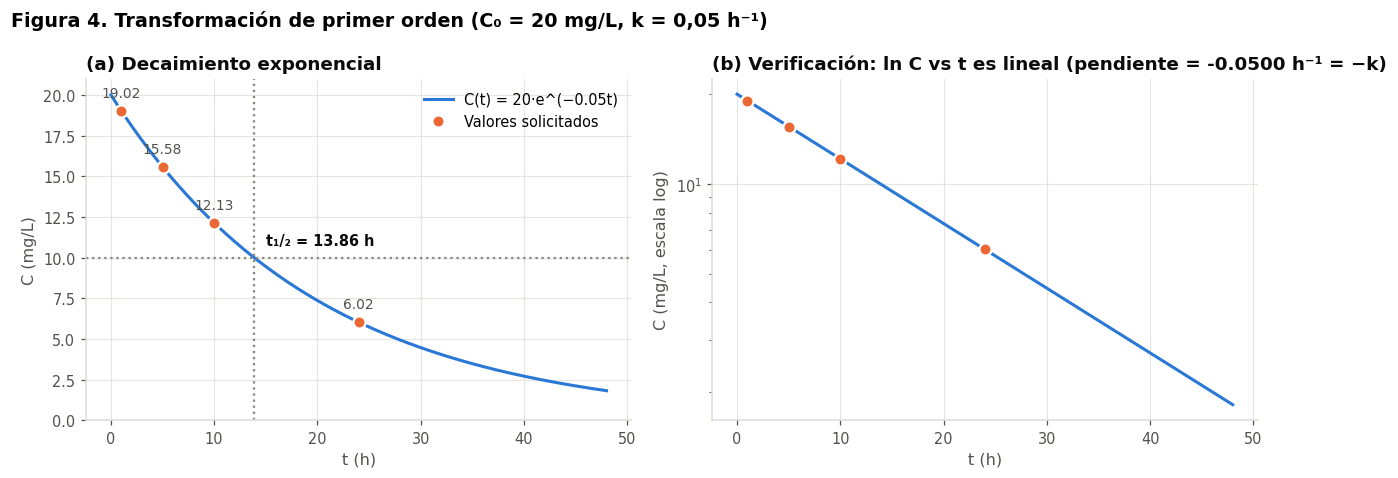

In [10]:
# ============================================================================
# ACTIVIDAD 4 — Gráficas: curva de decaimiento y verificación semilogarítmica
# ============================================================================
t_curva = np.linspace(0, 48, 400)
C_curva = c_primer_orden(t_curva, C0_a4, k_a4)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4))

# (a) Escala lineal
ax = axes[0]
ax.plot(t_curva, C_curva, color=COL["s1"], label="C(t) = 20·e^(−0.05t)")
ax.plot(t_eval[1:], C_eval[1:], "o", color=COL["s2"], markersize=8, zorder=3,
        markeredgecolor="white", markeredgewidth=1.5, label="Valores solicitados")
for t, C in zip(t_eval[1:], C_eval[1:]):
    ax.annotate(f"{C:.2f}", xy=(t, C), xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=9, color=COL["ink2"])
ax.axhline(C0_a4/2, color=COL["muted"], linestyle=":", linewidth=1.5)
ax.axvline(t_med,  color=COL["muted"], linestyle=":", linewidth=1.5)
ax.annotate(f"t₁/₂ = {t_med:.2f} h", xy=(t_med, C0_a4/2), xytext=(8, 8),
            textcoords="offset points", fontsize=9.5, color=COL["ink"], fontweight="bold")
ax.set_title("(a) Decaimiento exponencial"); ax.set_xlabel("t (h)"); ax.set_ylabel("C (mg/L)")
ax.set_ylim(0, 21); ax.legend(loc="upper right")

# (b) Escala semilogarítmica: recta de pendiente -k
ax = axes[1]
ax.semilogy(t_curva, C_curva, color=COL["s1"])
ax.plot(t_eval[1:], C_eval[1:], "o", color=COL["s2"], markersize=8, zorder=3,
        markeredgecolor="white", markeredgewidth=1.5)
pend_ln = np.polyfit(t_curva, np.log(C_curva), 1)[0]
ax.set_title(f"(b) Verificación: ln C vs t es lineal (pendiente = {pend_ln:.4f} h⁻¹ = −k)")
ax.set_xlabel("t (h)"); ax.set_ylabel("C (mg/L, escala log)")

fig.suptitle("Figura 4. Transformación de primer orden (C₀ = 20 mg/L, k = 0,05 h⁻¹)",
             fontsize=12.5, fontweight="bold", x=0.005, ha="left")
fig.tight_layout()
guardar(fig, "fig04_primer_orden"); plt.show()

### 4.5 Interpretación

La concentración cae de 20 mg/L a 19,02 mg/L (1 h), 15,58 mg/L (5 h), 12,13 mg/L (10 h) y
6,02 mg/L (24 h). La pérdida **no es lineal**: en la primera hora se pierde ~1 mg/L, mientras
que entre las horas 23 y 24 la pérdida es de solo ~0,31 mg/L, porque la velocidad de reacción
$-kC$ es proporcional a la concentración que aún queda.

La **vida media es $t_{1/2}=\ln 2/k = 13{,}86$ h**, independiente de $C_0$: partiendo de 20, 200 o
2 mg/L siempre se tardaría lo mismo en reducir la concentración a la mitad. El panel (b)
confirma que $\ln C$ vs. $t$ es una recta de pendiente $-k=-0{,}05$ h⁻¹, que es el criterio para
identificar experimentalmente una cinética de primer orden.

---
# ACTIVIDAD 5. ESTIMACIÓN DE LA CONSTANTE DE TRANSFORMACIÓN

### 5.1 Objetivo
Estimar $k$ utilizando mediciones de concentración.

### 5.2 Desarrollo matemático
Partiendo de la solución del primer orden y despejando $k$:

$$C = C_0 e^{-kt}\;\Rightarrow\;\frac{C}{C_0}=e^{-kt}\;\Rightarrow\;
\ln\!\left(\frac{C}{C_0}\right) = -kt \;\Rightarrow\;
\boxed{k = -\frac{1}{t}\ln\!\left(\frac{C}{C_0}\right)}$$

Con **dos** mediciones se obtiene un valor puntual de $k$; con una serie temporal lo correcto es
ajustar por regresión lineal $\ln(C/C_0)$ vs. $t$, cuya pendiente es $-k$.

### 5.3 Ejercicio
$C_0 = 20$ mg/L y, tras 10 días, $C = 10$ mg/L. Se pide $k$, la vida media y la concentración
esperada a 20 y 30 días.

In [11]:
# ============================================================================
# ACTIVIDAD 5 — Estimación de k a partir de mediciones
# ============================================================================
C0_a5, C_obs, t_obs = 20.0, 10.0, 10.0     # mg/L, mg/L, días

k_a5   = -(1/t_obs) * np.log(C_obs/C0_a5)
tm_a5  = vida_media(k_a5)
C_20d  = c_primer_orden(20.0, C0_a5, k_a5)
C_30d  = c_primer_orden(30.0, C0_a5, k_a5)

a5 = pd.DataFrame([
    ["Constante de transformación", "k = −(1/t)·ln(C/C₀) = −(1/10)·ln(0.5)", k_a5,  "d⁻¹"],
    ["Vida media",                  "t₁/₂ = ln2 / k",                        tm_a5, "d"],
    ["Concentración a 20 días",     "C = 20·e^(−0.06931·20)",                C_20d, "mg/L"],
    ["Concentración a 30 días",     "C = 20·e^(−0.06931·30)",                C_30d, "mg/L"],
], columns=["Magnitud", "Expresión", "Resultado", "Unidad"])
tabla(a5, "act5_estimacion_k", "Tabla 5.1 — Estimación de k y proyección de la concentración")

# --- Serie proyectada completa ---
t_serie = np.arange(0, 61, 5.0)
a5b = pd.DataFrame({
    "t (d)": t_serie,
    "C (mg/L)": c_primer_orden(t_serie, C0_a5, k_a5),
    "C/C₀": np.exp(-k_a5*t_serie),
    "Nº de vidas medias": t_serie/tm_a5,
    "Remoción (%)": 100*(1-np.exp(-k_a5*t_serie)),
})
tabla(a5b, "act5_proyeccion", "Tabla 5.2 — Proyección de la concentración hasta 60 días")

anotar("A5_k", k_a5, "d⁻¹", "Constante de transformación estimada")
anotar("A5_t_medio", tm_a5, "d", "Vida media estimada")
anotar("A5_C_20d", C_20d, "mg/L", "Concentración esperada a 20 días")
anotar("A5_C_30d", C_30d, "mg/L", "Concentración esperada a 30 días")

print(f"k = {k_a5:.5f} d⁻¹   |   t₁/₂ = {tm_a5:.2f} d")
print("Observación: como C cae a la mitad justo en t = 10 d, la vida media coincide con el")
print("tiempo de muestreo; 20 d = 2 vidas medias (C₀/4 = 5 mg/L) y 30 d = 3 vidas medias (C₀/8 = 2.5 mg/L).")

**Tabla 5.1 — Estimación de k y proyección de la concentración**  ·  `resultados/act5_estimacion_k.csv`

Magnitud,Expresión,Resultado,Unidad
Constante de transformación,k = −(1/t)·ln(C/C₀) = −(1/10)·ln(0.5),0.0693,d⁻¹
Vida media,t₁/₂ = ln2 / k,10.0000,d
Concentración a 20 días,C = 20·e^(−0.06931·20),5.0000,mg/L
Concentración a 30 días,C = 20·e^(−0.06931·30),2.5000,mg/L


**Tabla 5.2 — Proyección de la concentración hasta 60 días**  ·  `resultados/act5_proyeccion.csv`

t (d),C (mg/L),C/C₀,Nº de vidas medias,Remoción (%)
0.0000,20.0000,1.0000,0.0000,0.0000
5.0000,14.1421,0.7071,0.5000,29.2893
10.0000,10.0000,0.5000,1.0000,50.0000
15.0000,7.0711,0.3536,1.5000,64.6447
20.0000,5.0000,0.2500,2.0000,75.0000
25.0000,3.5355,0.1768,2.5000,82.3223
30.0000,2.5000,0.1250,3.0000,87.5000
35.0000,1.7678,0.0884,3.5000,91.1612
40.0000,1.2500,0.0625,4.0000,93.7500
45.0000,0.8839,0.0442,4.5000,95.5806


k = 0.06931 d⁻¹   |   t₁/₂ = 10.00 d
Observación: como C cae a la mitad justo en t = 10 d, la vida media coincide con el
tiempo de muestreo; 20 d = 2 vidas medias (C₀/4 = 5 mg/L) y 30 d = 3 vidas medias (C₀/8 = 2.5 mg/L).


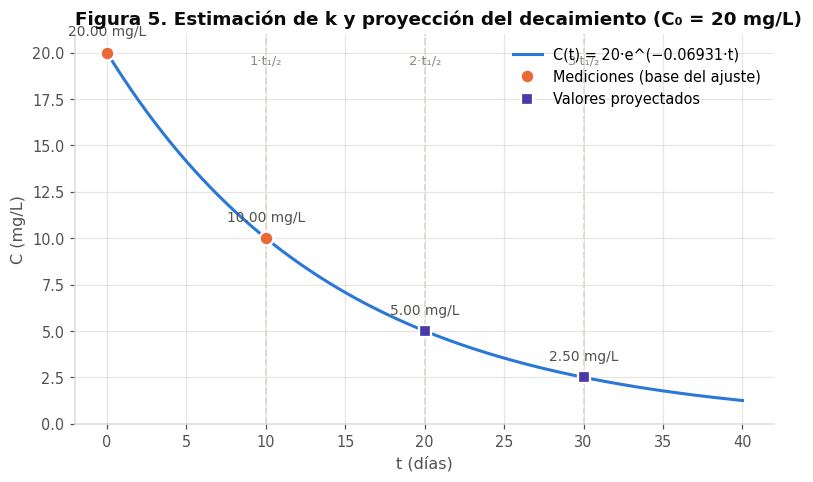

In [12]:
# ============================================================================
# ACTIVIDAD 5 — Gráfica: ajuste y proyección
# ============================================================================
t_c = np.linspace(0, 40, 400)
C_c = c_primer_orden(t_c, C0_a5, k_a5)

fig, ax = plt.subplots()
ax.plot(t_c, C_c, color=COL["s1"], label=f"C(t) = 20·e^(−{k_a5:.5f}·t)")
ax.plot([0, t_obs], [C0_a5, C_obs], "o", color=COL["s2"], markersize=9, zorder=4,
        markeredgecolor="white", markeredgewidth=1.5, label="Mediciones (base del ajuste)")
ax.plot([20, 30], [C_20d, C_30d], "s", color=COL["s4"], markersize=8, zorder=4,
        markeredgecolor="white", markeredgewidth=1.5, label="Valores proyectados")

for t, C in [(0, C0_a5), (t_obs, C_obs), (20, C_20d), (30, C_30d)]:
    ax.annotate(f"{C:.2f} mg/L", xy=(t, C), xytext=(0, 11), textcoords="offset points",
                ha="center", fontsize=9, color=COL["ink2"])

for n in (1, 2, 3):
    ax.axvline(n*tm_a5, color=COL["grid"], linestyle="--", linewidth=1.2, zorder=0)
    ax.annotate(f"{n}·t₁/₂", xy=(n*tm_a5, 19.4), fontsize=8.5, color=COL["muted"], ha="center")

ax.set_title("Figura 5. Estimación de k y proyección del decaimiento (C₀ = 20 mg/L)")
ax.set_xlabel("t (días)"); ax.set_ylabel("C (mg/L)")
ax.set_ylim(0, 21); ax.legend()
guardar(fig, "fig05_estimacion_k"); plt.show()

### 5.4 Interpretación

$k = 0{,}06931\ \mathrm{d^{-1}}$, es decir, se transforma aproximadamente el **6,7 % de la masa
remanente cada día**. Como la muestra a 10 días es exactamente la mitad de $C_0$, la vida media
coincide con el tiempo de muestreo ($t_{1/2}=10$ d), y las proyecciones son múltiplos exactos:
5 mg/L a 20 días (dos vidas medias) y 2,5 mg/L a 30 días (tres vidas medias).

**Limitación del procedimiento:** con solo dos puntos no es posible verificar que la cinética sea
realmente de primer orden ni estimar la incertidumbre de $k$. Dos mediciones siempre pueden
unirse con una exponencial. Para un valor defendible se requiere una serie temporal y una
regresión de $\ln C$ vs. $t$ con su $R^2$ e intervalo de confianza.

---
# ACTIVIDAD 6. ADVECCIÓN + TRANSFORMACIÓN

### 6.1 Objetivo
Integrar el transporte advectivo y la transformación química de primer orden.

### 6.2 Desarrollo matemático
La ecuación de gobierno incorpora ahora un sumidero:

$$\frac{\partial C}{\partial t} + u\frac{\partial C}{\partial x} = -kC$$

El miembro izquierdo es exactamente la derivada material $dC/dt$ siguiendo la parcela, de modo
que sobre la característica el problema se reduce a una EDO idéntica a la de la Actividad 4:

$$\frac{dC}{dt} = -kC \;\Longrightarrow\; C = C_0 e^{-kt}$$

Y como la parcela viaja según $x=ut$, el **tiempo de viaje** es $t = x/u$. Sustituyendo:

$$\boxed{C(x) = C_0\,e^{-kx/u}}$$

Esta es la solución **estacionaria** de un vertido continuo: la concentración depende solo de la
distancia, y el parámetro que la controla es el cociente $k/u$ (inverso de una longitud
característica $L_c = u/k$, la distancia en la que la concentración cae a $1/e \approx 37\%$).

### 6.3 Ejercicio
$C_0 = 10$ mg/L, $u = 0{,}25$ m/s, $k = 0{,}05\ \mathrm{h^{-1}}$; se evalúa a 1, 5 y 10 km.
**Coherencia dimensional:** $k$ está en h⁻¹ y $x$ en km, por lo que $u$ se convierte a km/h.

In [13]:
# ============================================================================
# ACTIVIDAD 6 — Advección + transformación:  C(x) = C0 exp(-k x / u)
# ============================================================================
C0_a6 = 10.0                       # mg/L
u_ms  = 0.25                       # m/s
k_a6  = 0.05                       # 1/h
u_kmh = u_ms * 3600 / 1000         # km/h  ->  0.90

print(f"Conversión de unidades: {u_ms} m/s × 3600 s/h ÷ 1000 m/km = {u_kmh:.2f} km/h")
print(f"Longitud característica L_c = u/k = {u_kmh/k_a6:.2f} km  (caída al 36.8 % de C0)\n")

x_km = np.array([0.0, 1.0, 5.0, 10.0])
C_x  = c_adv_reac(x_km, C0_a6, u_kmh, k_a6)

a6 = pd.DataFrame({
    "x (km)": x_km,
    "t de viaje = x/u (h)": x_km/u_kmh,
    "k·x/u": k_a6*x_km/u_kmh,
    "e^(−k·x/u)": np.exp(-k_a6*x_km/u_kmh),
    "C (mg/L)": C_x,
    "Remanente (%)": 100*C_x/C0_a6,
    "Removido (%)": 100*(1-C_x/C0_a6),
})
tabla(a6, "act6_adveccion_transformacion",
      "Tabla 6.1 — Concentración con advección y transformación (u = 0,90 km/h; k = 0,05 h⁻¹)")

for x, C in zip(x_km[1:], C_x[1:]):
    anotar(f"A6_C_{int(x)}km", C, "mg/L", f"Concentración a x={int(x)} km (u=0.9 km/h, k=0.05 1/h)")
anotar("A6_u_kmh", u_kmh, "km/h", "Velocidad convertida a km/h")
anotar("A6_Lc", u_kmh/k_a6, "km", "Longitud característica u/k")

Conversión de unidades: 0.25 m/s × 3600 s/h ÷ 1000 m/km = 0.90 km/h
Longitud característica L_c = u/k = 18.00 km  (caída al 36.8 % de C0)



**Tabla 6.1 — Concentración con advección y transformación (u = 0,90 km/h; k = 0,05 h⁻¹)**  ·  `resultados/act6_adveccion_transformacion.csv`

x (km),t de viaje = x/u (h),k·x/u,e^(−k·x/u),C (mg/L),Remanente (%),Removido (%)
0.0000,0.0000,0.0000,1.0000,10.0000,100.0000,0.0000
1.0000,1.1111,0.0556,0.9460,9.4596,94.5959,5.4041
5.0000,5.5556,0.2778,0.7575,7.5747,75.7465,24.2535
10.0000,11.1111,0.5556,0.5738,5.7375,57.3753,42.6247


18.0

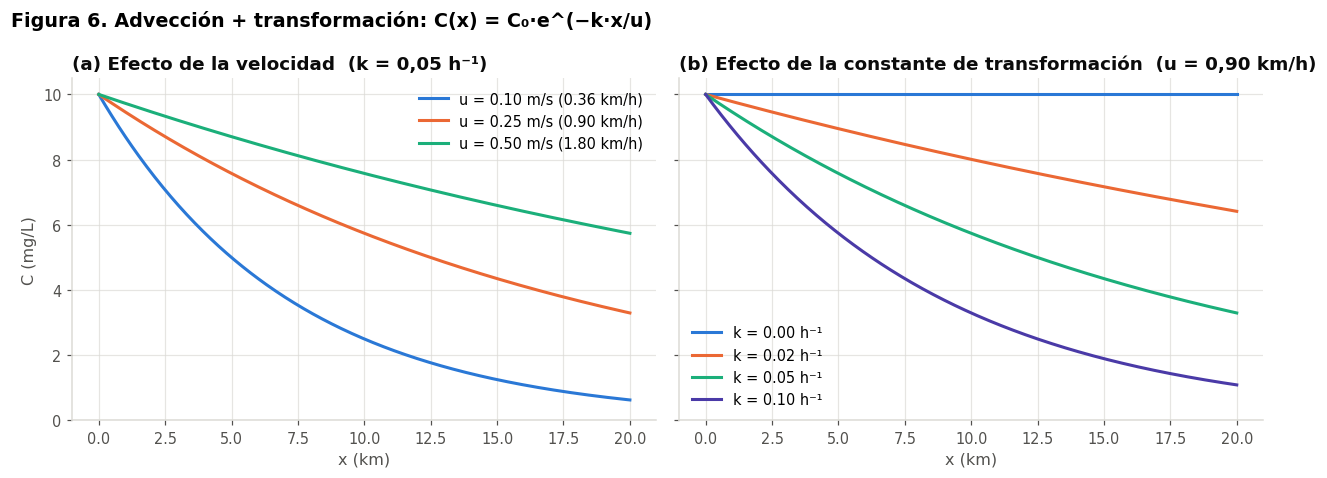

**Tabla 6.2 — Efecto de la velocidad sobre C(x) (pregunta 22 y 26)**  ·  `resultados/act6_sensibilidad_u.csv`

x (km),C (mg/L) | u=0.10 m/s,C (mg/L) | u=0.25 m/s,C (mg/L) | u=0.50 m/s
1,8.7032,9.4596,9.7260
5,4.9935,7.5747,8.7032
10,2.4935,5.7375,7.5747


**Tabla 6.3 — Efecto de k sobre C(x) (preguntas 23 y 25)**  ·  `resultados/act6_sensibilidad_k.csv`

x (km),C (mg/L) | k=0.00 h⁻¹,C (mg/L) | k=0.02 h⁻¹,C (mg/L) | k=0.05 h⁻¹,C (mg/L) | k=0.10 h⁻¹
1,10.0000,9.7802,9.4596,8.9484
5,10.0000,8.9484,7.5747,5.7375
10,10.0000,8.0074,5.7375,3.2919


,x (km),C (mg/L) | k=0.00 h⁻¹,C (mg/L) | k=0.02 h⁻¹,C (mg/L) | k=0.05 h⁻¹,C (mg/L) | k=0.10 h⁻¹
0,1,10.0,9.780229,9.459595,8.948393
1,5,10.0,8.948393,7.574651,5.737534
2,10,10.0,8.007374,5.737534,3.291930


In [14]:
# ============================================================================
# ACTIVIDAD 6 — Preguntas 22 a 27: efecto de u y de k sobre C(x)
# ============================================================================
x_c = np.linspace(0, 20, 400)

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.4), sharey=True)

# (a) Variación de u con k constante  (preguntas 22 y 26)
ax = axes[0]
for u_i, c in zip([0.10, 0.25, 0.50], SERIES):
    u_i_kmh = u_i*3.6
    ax.plot(x_c, c_adv_reac(x_c, C0_a6, u_i_kmh, k_a6), color=c,
            label=f"u = {u_i:.2f} m/s ({u_i_kmh:.2f} km/h)")
ax.set_title("(a) Efecto de la velocidad  (k = 0,05 h⁻¹)")
ax.set_xlabel("x (km)"); ax.set_ylabel("C (mg/L)"); ax.legend(); ax.set_ylim(0, 10.5)

# (b) Variación de k con u constante  (preguntas 23 y 25)
ax = axes[1]
for k_i, c in zip([0.0, 0.02, 0.05, 0.10], SERIES):
    ax.plot(x_c, c_adv_reac(x_c, C0_a6, u_kmh, k_i), color=c, label=f"k = {k_i:.2f} h⁻¹")
ax.set_title("(b) Efecto de la constante de transformación  (u = 0,90 km/h)")
ax.set_xlabel("x (km)"); ax.legend()

fig.suptitle("Figura 6. Advección + transformación: C(x) = C₀·e^(−k·x/u)",
             fontsize=12.5, fontweight="bold", x=0.005, ha="left")
fig.tight_layout()
guardar(fig, "fig06_adveccion_transformacion"); plt.show()

# --- Tablas de apoyo ---
sens_u = pd.DataFrame({"x (km)": [1, 5, 10]})
for u_i in [0.10, 0.25, 0.50]:
    sens_u[f"C (mg/L) | u={u_i:.2f} m/s"] = c_adv_reac(sens_u["x (km)"].values, C0_a6, u_i*3.6, k_a6)
tabla(sens_u, "act6_sensibilidad_u", "Tabla 6.2 — Efecto de la velocidad sobre C(x) (pregunta 22 y 26)")

sens_k = pd.DataFrame({"x (km)": [1, 5, 10]})
for k_i in [0.0, 0.02, 0.05, 0.10]:
    sens_k[f"C (mg/L) | k={k_i:.2f} h⁻¹"] = c_adv_reac(sens_k["x (km)"].values, C0_a6, u_kmh, k_i)
tabla(sens_k, "act6_sensibilidad_k", "Tabla 6.3 — Efecto de k sobre C(x) (preguntas 23 y 25)")

### 6.4 Respuestas a las preguntas 22 a 27

**22. ¿Cómo influye la velocidad sobre la concentración?**  
A mayor velocidad, menor tiempo de residencia $t=x/u$ para una misma distancia, y por tanto
**menos tiempo para transformarse**: la concentración que llega a un punto dado es *mayor*.
Con $u=0{,}10$ m/s a 10 km quedan 2,49 mg/L; con $u=0{,}25$ m/s, 5,74 mg/L, y con
$u=0{,}50$ m/s, 7,57 mg/L (Tabla 6.2). A la inversa,
si $u$ disminuye el contaminante permanece más tiempo en el sistema y se degrada más.

**23. ¿Qué ocurre si aumenta $k$?**  
El exponente $-kx/u$ se hace más negativo y la concentración decae más rápido con la distancia.
A 10 km: 10,00 mg/L con $k=0$; 8,00 con $k=0{,}02$; 5,74 con $k=0{,}05$ y 3,29 mg/L con
$k=0{,}10$ h⁻¹. La longitud característica $L_c=u/k$ se acorta.

**25. ¿Qué ocurre si $k=0$?**  
No hay transformación: $C(x)=C_0e^{0}=C_0$. La curva es horizontal (Figura 6b) y se recupera el
caso de **advección pura** de la Actividad 1: el contaminante solo se traslada.

**26–27. ¿Qué ocurre si $u$ aumenta manteniendo $k$ constante?**  
La curva $C(x)$ se vuelve más tendida: la pérdida por unidad de distancia, $-dC/dx = (k/u)C$,
disminuye. En el límite $u\to\infty$ la concentración no alcanzaría a degradarse y sería $C_0$ en
todo el dominio. Consecuencia práctica: **en crecida (u alta) el impacto se traslada más lejos y
más concentrado**; en estiaje (u baja) la carga se atenúa más cerca del vertido, pero el
tramo próximo queda expuesto durante más tiempo.

---
# ACTIVIDAD 7. ADVECCIÓN + DISPERSIÓN

### 7.1 Objetivo
Analizar simultáneamente el desplazamiento y el ensanchamiento de una nube contaminante.

### 7.2 Desarrollo matemático
La ecuación de advección-dispersión (ADE) para un contaminante conservativo es

$$\frac{\partial C}{\partial t} + u\frac{\partial C}{\partial x} = D_x\frac{\partial^2 C}{\partial x^2}$$

Con el cambio de variable a un sistema móvil $\xi = x - ut$ (que viaja con el flujo), la
advección desaparece y la ecuación se reduce a la de difusión pura resuelta en la Actividad 2.
Deshaciendo el cambio, para un pulso instantáneo de masa $M$:

$$\boxed{C(x,t)=\frac{M}{\sqrt{4\pi D_x t}}\;\exp\!\left[-\frac{(x-ut)^2}{4D_x t}\right]}$$

Es decir, una **gaussiana cuyo centro viaja a velocidad $u$** y cuyo ancho crece con $D_x$:

$$x_{\max}=u\,t,\qquad C_{\max}=\frac{M}{\sqrt{4\pi D_x t}},\qquad \sigma_x=\sqrt{2D_xt}$$

**Los dos procesos son independientes:** $u$ controla *dónde* está la nube y $D_x$ controla
*cuán ancha y cuán alta* es.

### 7.3 Ejercicio
$M=1000$ mg, $u=0{,}25$ m/s, $t=1$ h; se comparan $D_x = 50$, 100 y 200 m²/s.

In [15]:
# ============================================================================
# ACTIVIDAD 7 — Advección + dispersión: comparación de Dx a t = 1 h
# ============================================================================
M_a7, u_a7, t_a7 = 1000.0, 0.25, 3600.0
Dx_lista = [50.0, 100.0, 200.0]

x_centro = u_a7 * t_a7
print(f"Centro de la nube: x = u·t = {u_a7} × {t_a7:.0f} = {x_centro:.0f} m  (igual para todo Dx)\n")

filas = []
for Dx in Dx_lista:
    s  = sigma_x(Dx, t_a7)
    cm = c_max_pulso(M_a7, Dx, t_a7)
    filas.append([Dx, x_centro, cm, 2*Dx*t_a7, s, 4*s])
a7 = pd.DataFrame(filas, columns=[
    "Dx (m²/s)", "x_max = u·t (m)", "C_max (mg/m)", "σₓ² = 2Dx·t (m²)",
    "σₓ (m)", "Ancho ±2σ (m)"])
tabla(a7, "act7_adveccion_dispersion",
      "Tabla 7.1 — Advección + dispersión a t = 1 h (M = 1000 mg, u = 0,25 m/s)")

for Dx in Dx_lista:
    anotar(f"A7_Cmax_Dx{int(Dx)}", c_max_pulso(M_a7, Dx, t_a7), "mg/m", f"C_max con Dx={Dx:.0f} m²/s a t=1 h")
    anotar(f"A7_sigma_Dx{int(Dx)}", sigma_x(Dx, t_a7), "m", f"sigma_x con Dx={Dx:.0f} m²/s a t=1 h")
anotar("A7_x_centro", x_centro, "m", "Posición del centro de la nube a t=1 h")

# --- Perfil de concentración en puntos seleccionados ---
x_sel = np.array([0, 300, 600, 900, 1200, 1500, 1800, 2100])
a7b = pd.DataFrame({"x (m)": x_sel})
for Dx in Dx_lista:
    a7b[f"C (mg/m) | Dx={int(Dx)}"] = c_adv_disp(x_sel, t_a7, M_a7, u_a7, Dx)
tabla(a7b, "act7_perfil_C", "Tabla 7.2 — Perfil C(x) a t = 1 h para los tres valores de Dx")

# --- Control de masa ---
xx = np.linspace(-8000, 12000, 400001)
print("Control de masa por integración numérica:")
for Dx in Dx_lista:
    print(f"  Dx = {Dx:6.1f} m²/s -> M = {masa_numerica(xx, c_adv_disp(xx, t_a7, M_a7, u_a7, Dx)):.2f} mg")

Centro de la nube: x = u·t = 0.25 × 3600 = 900 m  (igual para todo Dx)



**Tabla 7.1 — Advección + dispersión a t = 1 h (M = 1000 mg, u = 0,25 m/s)**  ·  `resultados/act7_adveccion_dispersion.csv`

Dx (m²/s),x_max = u·t (m),C_max (mg/m),σₓ² = 2Dx·t (m²),σₓ (m),Ancho ±2σ (m)
50.0000,900.0000,0.6649,360000.0000,600.0000,2400.0000
100.0000,900.0000,0.4702,720000.0000,848.5281,3394.1125
200.0000,900.0000,0.3325,1440000.0000,1200.0000,4800.0000


**Tabla 7.2 — Perfil C(x) a t = 1 h para los tres valores de Dx**  ·  `resultados/act7_perfil_C.csv`

x (m),C (mg/m) | Dx=50,C (mg/m) | Dx=100,C (mg/m) | Dx=200
0,0.2159,0.2679,0.2509
300,0.4033,0.3662,0.2934
600,0.5868,0.4417,0.3222
900,0.6649,0.4702,0.3325
1200,0.5868,0.4417,0.3222
1500,0.4033,0.3662,0.2934
1800,0.2159,0.2679,0.2509
2100,0.0900,0.1730,0.2016


Control de masa por integración numérica:
  Dx =   50.0 m²/s -> M = 1000.00 mg
  Dx =  100.0 m²/s -> M = 1000.00 mg
  Dx =  200.0 m²/s -> M = 1000.00 mg


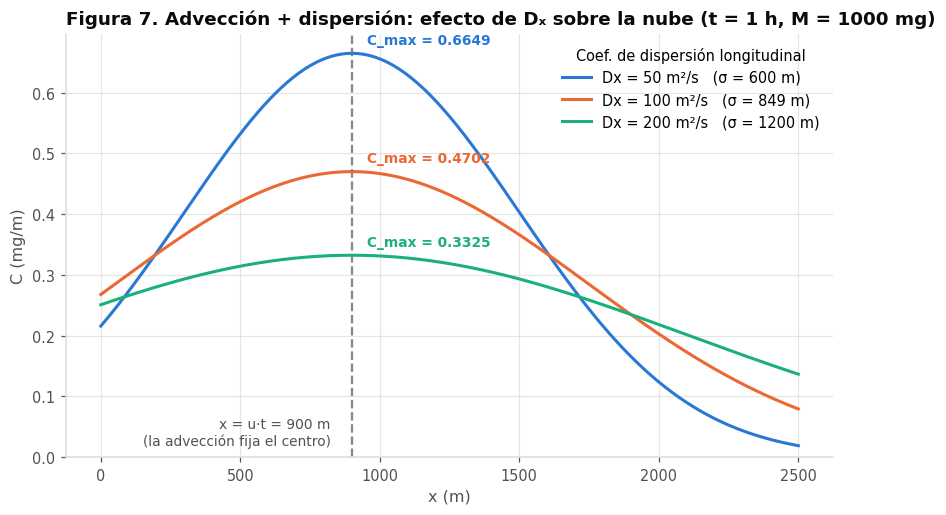

In [16]:
# ============================================================================
# ACTIVIDAD 7 — Gráfica: distribución C(x) a t = 1 h para distintos Dx
# ============================================================================
x_p = np.linspace(0, 2500, 800)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
for Dx, c in zip(Dx_lista, SERIES):
    Cp = c_adv_disp(x_p, t_a7, M_a7, u_a7, Dx)
    ax.plot(x_p, Cp, color=c, label=f"Dx = {Dx:.0f} m²/s   (σ = {sigma_x(Dx,t_a7):.0f} m)")
    ax.annotate(f"C_max = {Cp.max():.4f}", xy=(x_centro, Cp.max()), xytext=(10, 6),
                textcoords="offset points", fontsize=9, color=c, fontweight="bold")

ax.axvline(x_centro, color=COL["muted"], linestyle="--", linewidth=1.5, zorder=0)
ax.annotate("x = u·t = 900 m\n(la advección fija el centro)", xy=(x_centro, 0.02),
            xytext=(-14, 0), textcoords="offset points", ha="right",
            fontsize=9, color=COL["ink2"])
ax.set_title("Figura 7. Advección + dispersión: efecto de Dₓ sobre la nube (t = 1 h, M = 1000 mg)")
ax.set_xlabel("x (m)"); ax.set_ylabel("C (mg/m)")
ax.set_ylim(bottom=0); ax.legend(title="Coef. de dispersión longitudinal", title_fontsize=9.5)
guardar(fig, "fig07_adveccion_dispersion"); plt.show()

### 7.4 Respuestas a las preguntas 28 a 32

**28. ¿Qué proceso desplaza la nube?**  
La **advección**, representada por el término $u\,\partial C/\partial x$. Traslada el centro de
masa hasta $x = ut = 900$ m en 1 h, sin alterar la forma de la distribución.

**29. ¿Qué proceso la ensancha?**  
La **dispersión longitudinal**, representada por $D_x\,\partial^2C/\partial x^2$. Produce
$\sigma_x=\sqrt{2D_xt}$: 600 m, 848,5 m y 1200 m para $D_x=50$, 100 y 200 m²/s.

**30. ¿Qué ocurre con la concentración máxima cuando aumenta $D_x$?**  
Disminuye como $C_{\max}\propto D_x^{-1/2}$: 0,6649 → 0,4702 → 0,3325 mg/m. Al duplicar $D_x$ el
pico se reduce en $1/\sqrt2 = 0{,}707$. La misma masa se reparte en un volumen mayor; la
integral de las tres curvas sigue siendo 1000 mg.

**31. ¿El centro de la nube cambia al modificar $D_x$?**  
No. El centro (y también la media y la moda de la distribución) permanece en $x=ut=900$ m para
los tres casos, porque $D_x$ solo aparece en la varianza. La dispersión es un proceso simétrico
respecto del centro de masa: ensancha, pero no traslada.

**32. ¿Qué parámetro controla principalmente la posición de la nube?**  
La **velocidad media del flujo $u$** (junto con el tiempo transcurrido). $D_x$ controla el ancho
y la altura; $u$ controla la posición.

---
# ACTIVIDAD 8. MODELO INTEGRADO ADVECCIÓN–DISPERSIÓN–TRANSFORMACIÓN

### 8.1 Objetivo
Integrar los procesos de transporte y transformación en un único modelo.

### 8.2 Desarrollo matemático
La ecuación completa reúne los tres mecanismos:

$$\frac{\partial C}{\partial t} + \underbrace{u\frac{\partial C}{\partial x}}_{\text{advección}}
= \underbrace{D_x\frac{\partial^2 C}{\partial x^2}}_{\text{dispersión}} - \underbrace{kC}_{\text{transformación}}$$

Sustituyendo $C = \tilde{C}\,e^{-kt}$, el término reactivo se cancela y $\tilde{C}$ satisface
exactamente la ADE conservativa de la Actividad 7. Por tanto la solución es el **producto** de la
gaussiana móvil por un factor de decaimiento uniforme:

$$\boxed{C(x,t)=\frac{M}{\sqrt{4\pi D_xt}}\exp\!\left[-\frac{(x-ut)^2}{4D_xt}\right]e^{-kt}}$$

**Consecuencia clave:** el factor $e^{-kt}$ **no depende de $x$**, así que la reacción escala toda
la curva verticalmente sin mover el centro ($x_{\max}=ut$) ni cambiar el ancho
($\sigma_x=\sqrt{2D_xt}$). Cada parámetro tiene un rol separado:

| Parámetro | Controla | Efecto en la curva |
|---|---|---|
| $u$ | posición | traslada el pico |
| $D_x$ | ancho y altura | ensancha y aplana |
| $k$ | masa remanente | baja toda la curva |

### 8.3 Parámetros y 8.4 escenarios
$M=1000$ mg, $u=0{,}25$ m/s, $D_x=50$ m²/s, $k=0{,}05$ h⁻¹, $t=1$ h.

- **Escenario A** — Advección: $D_x=0$; $k=0$.
- **Escenario B** — Advección + dispersión: $D_x=50$ m²/s; $k=0$.
- **Escenario C** — Advección + dispersión + transformación: $D_x=50$ m²/s; $k=0{,}05$ h⁻¹.

In [17]:
# ============================================================================
# ACTIVIDAD 8 — Modelo integrado: escenarios A, B y C (pregunta 33)
# ============================================================================
M_a8, u_a8, Dx_a8, k_a8, t_a8 = 1000.0, 0.25, 50.0, 0.05, 3600.0
x_max_a8 = u_a8 * t_a8

esc = pd.DataFrame([
    ["A: Advección",                            0.0,   0.0,  x_max_a8, np.nan,   0.0,      M_a8],
    ["B: Advección + dispersión",               Dx_a8, 0.0,  x_max_a8,
     c_max_pulso(M_a8, Dx_a8, t_a8, 0.0),  sigma_x(Dx_a8, t_a8),  M_a8],
    ["C: Advección + dispersión + transformación", Dx_a8, k_a8, x_max_a8,
     c_max_pulso(M_a8, Dx_a8, t_a8, k_a8), sigma_x(Dx_a8, t_a8),  M_a8*np.exp(-k_a8*t_a8/3600)],
], columns=["Escenario", "Dx (m²/s)", "k (h⁻¹)", "x_max (m)", "C_max (mg/m)", "σₓ (m)", "Masa remanente (mg)"])
esc["Ancho ±2σ (m)"] = 4*esc["σₓ (m)"]
tabla(esc, "act8_escenarios", "Tabla 8.1 — Resultados comparativos de los escenarios A, B y C")

print("Escenario A (Dx = 0, k = 0): la masa permanece concentrada en un punto que viaja con el")
print(f"flujo, x = u·t = {x_max_a8:.0f} m. Bajo la idealización de fuente puntual sin dispersión")
print("la solución es una delta de Dirac: C_max -> infinito y sigma = 0, por lo que NO existe una")
print("concentración máxima finita (por eso aparece como no definida en la tabla).\n")

f_decay = np.exp(-k_a8*t_a8/3600)
Cmax_B  = c_max_pulso(M_a8, Dx_a8, t_a8, 0.0)
Cmax_C  = c_max_pulso(M_a8, Dx_a8, t_a8, k_a8)
perdida = Cmax_B - Cmax_C

# Preguntas 35, 36, 37, 38
det = pd.DataFrame([
    ["35. C_max escenario B", Cmax_B, "mg/m"],
    ["35. C_max escenario C", Cmax_C, "mg/m"],
    ["36. Posición del máximo (A, B y C)", x_max_a8, "m"],
    ["37. σₓ escenarios B y C", sigma_x(Dx_a8, t_a8), "m"],
    ["38. Factor de supervivencia e^(−k·t)", f_decay, "-"],
    ["38. Pérdida absoluta de C_max", perdida, "mg/m"],
    ["38. Pérdida relativa de C_max", 100*perdida/Cmax_B, "%"],
    ["38. Masa transformada en 1 h", M_a8*(1-f_decay), "mg"],
], columns=["Concepto", "Valor", "Unidad"])
tabla(det, "act8_detalle", "Tabla 8.2 — Identificación del máximo, ancho y pérdida (preguntas 35 a 38)")

anotar("A8_Cmax_B", Cmax_B, "mg/m", "C_max escenario B")
anotar("A8_Cmax_C", Cmax_C, "mg/m", "C_max escenario C")
anotar("A8_perdida_pct", 100*perdida/Cmax_B, "%", "Pérdida relativa de C_max por transformación en 1 h")
anotar("A8_sigma", sigma_x(Dx_a8, t_a8), "m", "sigma_x escenarios B y C")
anotar("A8_xmax", x_max_a8, "m", "Posición del máximo en los tres escenarios")

print(f"Pérdida: {Cmax_B:.4f} − {Cmax_C:.4f} = {perdida:.4f} mg/m  ->  {100*perdida/Cmax_B:.2f} %")
print(f"Coincide exactamente con 1 − e^(−k·t) = 1 − {f_decay:.4f} = {100*(1-f_decay):.2f} %")

**Tabla 8.1 — Resultados comparativos de los escenarios A, B y C**  ·  `resultados/act8_escenarios.csv`

Escenario,Dx (m²/s),k (h⁻¹),x_max (m),C_max (mg/m),σₓ (m),Masa remanente (mg),Ancho ±2σ (m)
A: Advección,0.0000,0.0000,900.0000,nan,0.0000,1000.0000,0.0000
B: Advección + dispersión,50.0000,0.0000,900.0000,0.6649,600.0000,1000.0000,2400.0000
C: Advección + dispersión + transformación,50.0000,0.0500,900.0000,0.6325,600.0000,951.2294,2400.0000


Escenario A (Dx = 0, k = 0): la masa permanece concentrada en un punto que viaja con el
flujo, x = u·t = 900 m. Bajo la idealización de fuente puntual sin dispersión
la solución es una delta de Dirac: C_max -> infinito y sigma = 0, por lo que NO existe una
concentración máxima finita (por eso aparece como no definida en la tabla).



**Tabla 8.2 — Identificación del máximo, ancho y pérdida (preguntas 35 a 38)**  ·  `resultados/act8_detalle.csv`

Concepto,Valor,Unidad
35. C_max escenario B,0.6649,mg/m
35. C_max escenario C,0.6325,mg/m
"36. Posición del máximo (A, B y C)",900.0000,m
37. σₓ escenarios B y C,600.0000,m
38. Factor de supervivencia e^(−k·t),0.9512,-
38. Pérdida absoluta de C_max,0.0324,mg/m
38. Pérdida relativa de C_max,4.8771,%
38. Masa transformada en 1 h,48.7706,mg


Pérdida: 0.6649 − 0.6325 = 0.0324 mg/m  ->  4.88 %
Coincide exactamente con 1 − e^(−k·t) = 1 − 0.9512 = 4.88 %


**Tabla 8.3 — Perfil de concentración de los escenarios B y C**  ·  `resultados/act8_perfil_BC.csv`

x (m),B: C (mg/m),C: C (mg/m),Diferencia (mg/m),Diferencia (%)
0,0.2159,0.2053,0.0105,4.8771
300,0.4033,0.3836,0.0197,4.8771
600,0.5868,0.5582,0.0286,4.8771
900,0.6649,0.6325,0.0324,4.8771
1200,0.5868,0.5582,0.0286,4.8771
1500,0.4033,0.3836,0.0197,4.8771
1800,0.2159,0.2053,0.0105,4.8771
2100,0.0900,0.0856,0.0044,4.8771
2400,0.0292,0.0278,0.0014,4.8771


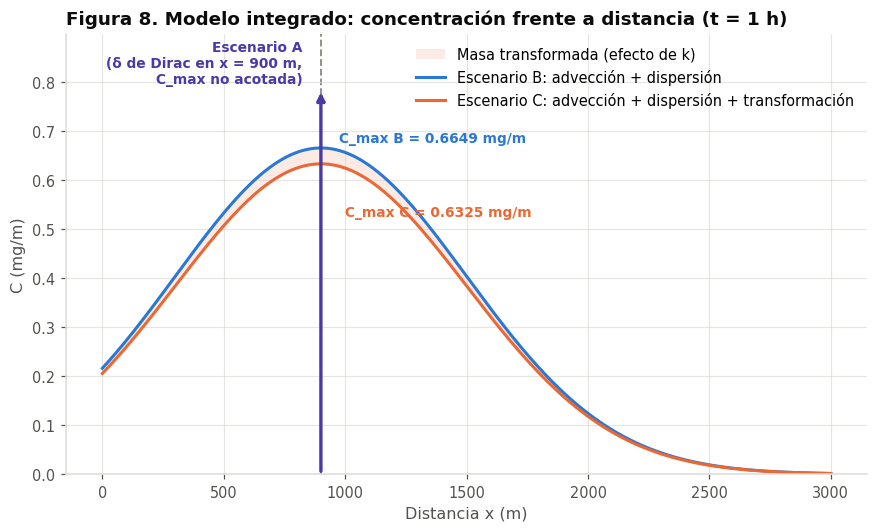

Control de masa (integración numérica):
  Escenario B: 1000.00 mg  (teórico 1000.00)
  Escenario C: 951.23 mg  (teórico 951.23)


In [18]:
# ============================================================================
# ACTIVIDAD 8 — Perfil C(x) y gráfica comparativa (pregunta 34)
# ============================================================================
x_sel8 = np.array([0, 300, 600, 900, 1200, 1500, 1800, 2100, 2400])
perf = pd.DataFrame({"x (m)": x_sel8})
perf["B: C (mg/m)"] = c_adv_disp(x_sel8, t_a8, M_a8, u_a8, Dx_a8)
perf["C: C (mg/m)"] = c_integrado(x_sel8, t_a8, M_a8, u_a8, Dx_a8, k_a8)
perf["Diferencia (mg/m)"] = perf["B: C (mg/m)"] - perf["C: C (mg/m)"]
perf["Diferencia (%)"] = 100*perf["Diferencia (mg/m)"]/perf["B: C (mg/m)"]
tabla(perf, "act8_perfil_BC", "Tabla 8.3 — Perfil de concentración de los escenarios B y C")

x_p8 = np.linspace(0, 3000, 900)
C_B  = c_adv_disp(x_p8, t_a8, M_a8, u_a8, Dx_a8)
C_C  = c_integrado(x_p8, t_a8, M_a8, u_a8, Dx_a8, k_a8)

fig, ax = plt.subplots(figsize=(9.4, 5.2))
ax.fill_between(x_p8, C_C, C_B, color=COL["s2"], alpha=0.13, lw=0,
                label="Masa transformada (efecto de k)")
ax.plot(x_p8, C_B, color=COL["s1"], label="Escenario B: advección + dispersión")
ax.plot(x_p8, C_C, color=COL["s2"], label="Escenario C: advección + dispersión + transformación")

# Escenario A: impulso idealizado en x = u t
ax.annotate("", xy=(x_max_a8, C_B.max()*1.18), xytext=(x_max_a8, 0),
            arrowprops=dict(arrowstyle="-|>", color=COL["s4"], linewidth=2.2))
ax.annotate("Escenario A\n(δ de Dirac en x = 900 m,\nC_max no acotada)",
            xy=(x_max_a8, C_B.max()*1.18), xytext=(-12, 4), textcoords="offset points",
            ha="right", fontsize=9, color=COL["s4"], fontweight="bold")

ax.axvline(x_max_a8, color=COL["muted"], linestyle="--", linewidth=1.2, zorder=0)
ax.annotate(f"C_max B = {Cmax_B:.4f} mg/m", xy=(x_max_a8, Cmax_B), xytext=(12, 4),
            textcoords="offset points", fontsize=9, color=COL["s1"], fontweight="bold")
ax.annotate(f"C_max C = {Cmax_C:.4f} mg/m", xy=(x_max_a8, Cmax_C), xytext=(16, -34),
            textcoords="offset points", fontsize=9, color=COL["s2"], fontweight="bold")

ax.set_title("Figura 8. Modelo integrado: concentración frente a distancia (t = 1 h)")
ax.set_xlabel("Distancia x (m)"); ax.set_ylabel("C (mg/m)")
ax.set_ylim(0, C_B.max()*1.35); ax.legend(loc="upper right")
guardar(fig, "fig08_modelo_integrado"); plt.show()

# --- Control de masa de cada escenario ---
xx = np.linspace(-10000, 15000, 500001)
print("Control de masa (integración numérica):")
print(f"  Escenario B: {masa_numerica(xx, c_adv_disp(xx, t_a8, M_a8, u_a8, Dx_a8)):.2f} mg  (teórico 1000.00)")
print(f"  Escenario C: {masa_numerica(xx, c_integrado(xx, t_a8, M_a8, u_a8, Dx_a8, k_a8)):.2f} mg  (teórico {M_a8*f_decay:.2f})")

### 8.5 Respuestas a las preguntas 33 a 39

**33–35. Concentración y máximo.** $C_{\max}^{B}=0{,}6649$ mg/m y $C_{\max}^{C}=0{,}6325$ mg/m.
En el escenario A, con $D_x=0$ y fuente puntual, no existe un máximo finito: toda la masa está
concentrada en $x=900$ m (delta de Dirac), lo que es una idealización matemática sin correlato
físico exacto.

**36. Posición del máximo.** $x_{\max}=ut=0{,}25\times3600=900$ m en **los tres escenarios**: ni
$D_x$ ni $k$ desplazan el centro de masa.

**37. Ancho de la distribución.** $\sigma_x=\sqrt{2D_xt}=600$ m en B y en C (idéntico, porque
comparten $D_x$); el escenario A no tiene ancho. La transformación **no modifica el ancho**, solo
la altura.

**38. Pérdida de concentración.** $0{,}6649-0{,}6325=0{,}0324$ mg/m, es decir **4,88 %**, que
coincide exactamente con $1-e^{-kt}=1-0{,}9512$. Como el factor es uniforme en $x$, la pérdida
relativa es la misma en todos los puntos del perfil (columna "Diferencia (%)" de la Tabla 8.3) y
equivale a 48,8 mg de masa transformada en 1 h.

**39. Proceso responsable de cada diferencia.**

| Diferencia observada | Proceso responsable | Parámetro |
|---|---|---|
| El pico está en 900 m y no en el origen | Advección | $u$ |
| La curva es una campana y no un pico | Dispersión longitudinal | $D_x$ |
| La curva de C está por debajo de la de B | Transformación de primer orden | $k$ |
| El área bajo la curva de C es 951,2 mg y no 1000 mg | Transformación (pérdida de masa) | $k$ |

Advección → **desplazamiento**; dispersión → **ensanchamiento**; transformación → **pérdida**.

---
# ACTIVIDAD 9. ANÁLISIS DE SENSIBILIDAD

### 9.1 Objetivo
Determinar la influencia de los principales parámetros sobre el comportamiento del contaminante.

### Marco de análisis
Se usa el modelo integrado con la configuración base $M=1000$ mg, $u=0{,}25$ m/s,
$D_x=50$ m²/s, $k=0{,}05$ h⁻¹, $t=1$ h, y se varía **un parámetro por vez** (análisis local
OAT, *one-at-a-time*). Se observan tres **variables de salida**:

$$x_{\max}=ut,\qquad C_{\max}=\frac{M}{\sqrt{4\pi D_xt}}e^{-kt},\qquad M_{rem}=M e^{-kt}$$

Además del análisis por escenarios, se calcula el **índice de sensibilidad adimensional
(elasticidad)**, que permite comparar parámetros con unidades distintas:

$$S_{p}^{Y}=\frac{\partial Y/Y}{\partial p/p}\approx\frac{\Delta Y/Y_0}{\Delta p/p_0}$$

Un valor $S=1$ significa que un aumento del 1 % en el parámetro produce un aumento del 1 % en la
salida; $S=0$ indica que la salida no depende de ese parámetro.

In [19]:
# ============================================================================
# ACTIVIDAD 9.2 — Variación de la velocidad (u = 0.10, 0.25, 0.50 m/s)
# ============================================================================
BASE = dict(M=1000.0, u=0.25, Dx=50.0, k=0.05, t=3600.0)   # k en 1/h, t en s

u_lista = [0.10, 0.25, 0.50]
s9u = pd.DataFrame({"u (m/s)": u_lista})
s9u["x_max = u·t (m)"] = [u*BASE["t"] for u in u_lista]
s9u["x_max (km)"]      = s9u["x_max = u·t (m)"]/1000
s9u["C_max (mg/m)"]    = c_max_pulso(BASE["M"], BASE["Dx"], BASE["t"], BASE["k"])
s9u["σₓ (m)"]          = sigma_x(BASE["Dx"], BASE["t"])
s9u["Tiempo hasta 5 km (h)"] = [5000/u/3600 for u in u_lista]
tabla(s9u, "act9_sensibilidad_u",
      "Tabla 9.1 — Sensibilidad a la velocidad (Dx = 50 m²/s, k = 0,05 h⁻¹, t = 1 h)")

# ============================================================================
# ACTIVIDAD 9.3 — Variación de la dispersión (Dx = 0, 50, 100, 200 m²/s)
# ============================================================================
Dx_lista9 = [0.0, 50.0, 100.0, 200.0]
filas = []
for Dx in Dx_lista9:
    if Dx == 0:
        filas.append([Dx, 0.0, np.nan, 0.0, "Sin dispersión (pulso puntual ideal)"])
    else:
        s = sigma_x(Dx, BASE["t"]); cm = c_max_pulso(BASE["M"], Dx, BASE["t"], BASE["k"])
        etiqueta = ("Dispersión moderada" if Dx == 50 else "Mayor ensanchamiento")
        filas.append([Dx, s, cm, 4*s, etiqueta])
s9d = pd.DataFrame(filas, columns=["Dx (m²/s)", "σₓ (m)", "C_max (mg/m)", "Ancho ±2σ (m)", "Comportamiento"])
tabla(s9d, "act9_sensibilidad_Dx",
      "Tabla 9.2 — Sensibilidad a la dispersión (u = 0,25 m/s, k = 0,05 h⁻¹, t = 1 h)")

# ============================================================================
# ACTIVIDAD 9.4 — Variación de la transformación (k = 0, 0.02, 0.05, 0.10 1/h)
# ============================================================================
k_lista = [0.0, 0.02, 0.05, 0.10]
s9k = pd.DataFrame({"k (h⁻¹)": k_lista})
s9k["e^(−k·t)"]            = [np.exp(-k*1.0) for k in k_lista]
s9k["Pérdida (%)"]         = 100*(1 - s9k["e^(−k·t)"])
s9k["C_max (mg/m)"]        = [c_max_pulso(BASE["M"], BASE["Dx"], BASE["t"], k) for k in k_lista]
s9k["Masa remanente (mg)"] = BASE["M"]*s9k["e^(−k·t)"]
s9k["Vida media (h)"]      = [np.inf if k == 0 else vida_media(k) for k in k_lista]
tabla(s9k, "act9_sensibilidad_k",
      "Tabla 9.3 — Sensibilidad a la transformación (u = 0,25 m/s, Dx = 50 m²/s, t = 1 h)")

anotar("A9_xmax_u010", 0.10*BASE["t"], "m", "x_max con u=0.10 m/s a t=1 h")
anotar("A9_xmax_u050", 0.50*BASE["t"], "m", "x_max con u=0.50 m/s a t=1 h")

**Tabla 9.1 — Sensibilidad a la velocidad (Dx = 50 m²/s, k = 0,05 h⁻¹, t = 1 h)**  ·  `resultados/act9_sensibilidad_u.csv`

u (m/s),x_max = u·t (m),x_max (km),C_max (mg/m),σₓ (m),Tiempo hasta 5 km (h)
0.1000,360.0000,0.3600,0.6325,600.0000,13.8889
0.2500,900.0000,0.9000,0.6325,600.0000,5.5556
0.5000,1800.0000,1.8000,0.6325,600.0000,2.7778


**Tabla 9.2 — Sensibilidad a la dispersión (u = 0,25 m/s, k = 0,05 h⁻¹, t = 1 h)**  ·  `resultados/act9_sensibilidad_Dx.csv`

Dx (m²/s),σₓ (m),C_max (mg/m),Ancho ±2σ (m),Comportamiento
0.0000,0.0000,nan,0.0000,Sin dispersión (pulso puntual ideal)
50.0000,600.0000,0.6325,2400.0000,Dispersión moderada
100.0000,848.5281,0.4472,3394.1125,Mayor ensanchamiento
200.0000,1200.0000,0.3162,4800.0000,Mayor ensanchamiento


**Tabla 9.3 — Sensibilidad a la transformación (u = 0,25 m/s, Dx = 50 m²/s, t = 1 h)**  ·  `resultados/act9_sensibilidad_k.csv`

k (h⁻¹),e^(−k·t),Pérdida (%),C_max (mg/m),Masa remanente (mg),Vida media (h)
0.0000,1.0000,0.0000,0.6649,1000.0000,inf
0.0200,0.9802,1.9801,0.6517,980.1987,34.6574
0.0500,0.9512,4.8771,0.6325,951.2294,13.8629
0.1000,0.9048,9.5163,0.6016,904.8374,6.9315


1800.0

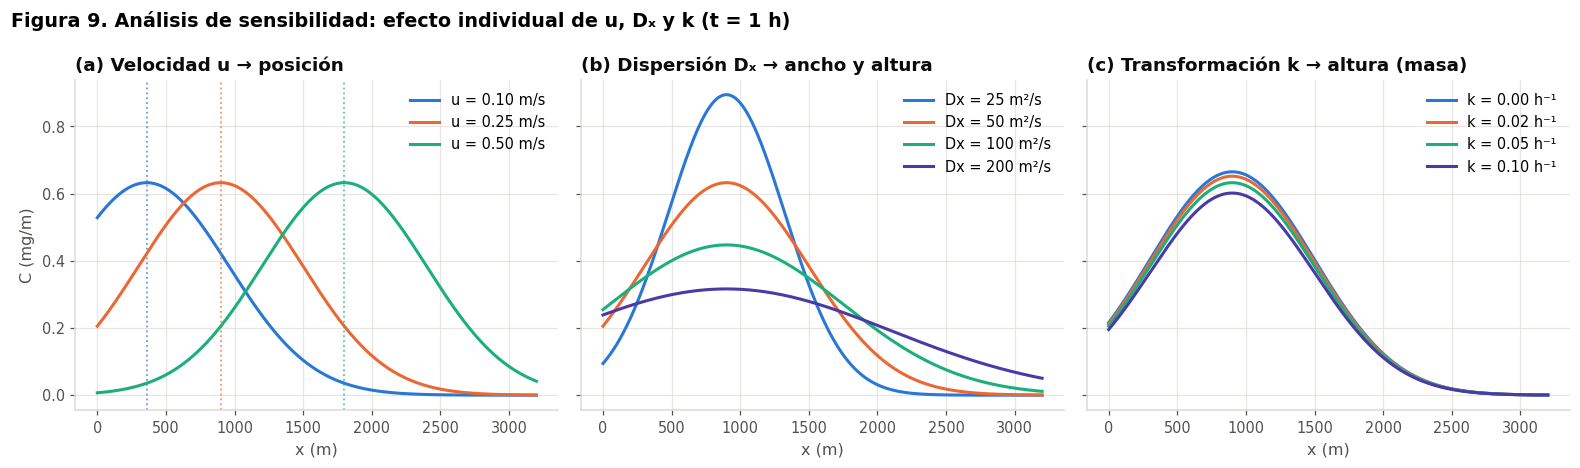

In [20]:
# ============================================================================
# ACTIVIDAD 9 — Figura de sensibilidad: un panel por parámetro
# ============================================================================
x9 = np.linspace(0, 3200, 900)
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.3), sharey=True)

# (a) Variación de u
ax = axes[0]
for u_i, c in zip(u_lista, SERIES):
    ax.plot(x9, c_integrado(x9, BASE["t"], BASE["M"], u_i, BASE["Dx"], BASE["k"]),
            color=c, label=f"u = {u_i:.2f} m/s")
    ax.axvline(u_i*BASE["t"], color=c, linestyle=":", linewidth=1.2, alpha=0.7)
ax.set_title("(a) Velocidad u → posición")
ax.set_xlabel("x (m)"); ax.set_ylabel("C (mg/m)"); ax.legend()

# (b) Variación de Dx
ax = axes[1]
for Dx_i, c in zip([25.0, 50.0, 100.0, 200.0], SERIES):
    ax.plot(x9, c_integrado(x9, BASE["t"], BASE["M"], BASE["u"], Dx_i, BASE["k"]),
            color=c, label=f"Dx = {Dx_i:.0f} m²/s")
ax.set_title("(b) Dispersión Dₓ → ancho y altura")
ax.set_xlabel("x (m)"); ax.legend()

# (c) Variación de k
ax = axes[2]
for k_i, c in zip(k_lista, SERIES):
    ax.plot(x9, c_integrado(x9, BASE["t"], BASE["M"], BASE["u"], BASE["Dx"], k_i),
            color=c, label=f"k = {k_i:.2f} h⁻¹")
ax.set_title("(c) Transformación k → altura (masa)")
ax.set_xlabel("x (m)"); ax.legend()

fig.suptitle("Figura 9. Análisis de sensibilidad: efecto individual de u, Dₓ y k (t = 1 h)",
             fontsize=12.5, fontweight="bold", x=0.005, ha="left")
fig.tight_layout()
guardar(fig, "fig09_sensibilidad_paneles"); plt.show()

In [21]:
# ============================================================================
# ACTIVIDAD 9 — Índices de sensibilidad adimensionales (elasticidades)
# ============================================================================
def salidas(u, Dx, k, M=1000.0, t=3600.0):
    """Devuelve las tres variables de respuesta del modelo integrado."""
    return {
        "x_max (m)":            u*t,
        "C_max (mg/m)":         M/np.sqrt(4*np.pi*Dx*t)*np.exp(-k*t/3600),
        "Masa remanente (mg)":  M*np.exp(-k*t/3600),
    }

base_out = salidas(BASE["u"], BASE["Dx"], BASE["k"])
delta = 0.10          # perturbación relativa: ±10 %

filas = []
for p in ["u", "Dx", "k"]:
    kw_hi = dict(u=BASE["u"], Dx=BASE["Dx"], k=BASE["k"])
    kw_lo = dict(kw_hi)
    kw_hi[p] = kw_hi[p]*(1+delta)
    kw_lo[p] = kw_lo[p]*(1-delta) if kw_lo[p] != 0 else 0.0
    out_hi, out_lo = salidas(**kw_hi), salidas(**kw_lo)
    for var in base_out:
        # diferencia central normalizada
        S = ((out_hi[var]-out_lo[var])/base_out[var]) / (2*delta)
        filas.append([p, var, base_out[var], out_lo[var], out_hi[var], S, abs(S)])

sens = pd.DataFrame(filas, columns=[
    "Parámetro", "Variable de salida", "Valor base", "−10 %", "+10 %",
    "Índice S (elasticidad)", "|S|"])
tabla(sens, "act9_indices_sensibilidad",
      "Tabla 9.4 — Índices de sensibilidad adimensionales (perturbación ±10 %)")

# --- Matriz resumen (parámetro x salida) ---
matriz = sens.pivot(index="Parámetro", columns="Variable de salida",
                    values="Índice S (elasticidad)").reset_index()
tabla(matriz, "act9_matriz_sensibilidad", "Tabla 9.5 — Matriz de elasticidades S(parámetro, salida)")

print("Valores analíticos esperados (comprobación):")
print("  x_max = u·t          -> S_u = 1 ; S_Dx = 0 ; S_k = 0")
print("  C_max ∝ Dx^(-1/2)    -> S_Dx = -0.5")
print(f"  C_max ∝ e^(-k t)     -> S_k = -k·t = {-BASE['k']*1.0:.2f}")
print(f"  Masa  ∝ e^(-k t)     -> S_k = -k·t = {-BASE['k']*1.0:.2f}")

**Tabla 9.4 — Índices de sensibilidad adimensionales (perturbación ±10 %)**  ·  `resultados/act9_indices_sensibilidad.csv`

Parámetro,Variable de salida,Valor base,−10 %,+10 %,Índice S (elasticidad),|S|
u,x_max (m),900.0000,810.0000,990.0000,1.0000,1.0000
u,C_max (mg/m),0.6325,0.6325,0.6325,0.0000,0.0000
u,Masa remanente (mg),951.2294,951.2294,951.2294,0.0000,0.0000
Dx,x_max (m),900.0000,900.0000,900.0000,0.0000,0.0000
Dx,C_max (mg/m),0.6325,0.6667,0.6030,-0.5031,0.5031
Dx,Masa remanente (mg),951.2294,951.2294,951.2294,0.0000,0.0000
k,x_max (m),900.0000,900.0000,900.0000,0.0000,0.0000
k,C_max (mg/m),0.6325,0.6356,0.6293,-0.0500,0.0500
k,Masa remanente (mg),951.2294,955.9975,946.4851,-0.0500,0.0500


**Tabla 9.5 — Matriz de elasticidades S(parámetro, salida)**  ·  `resultados/act9_matriz_sensibilidad.csv`

Parámetro,C_max (mg/m),Masa remanente (mg),x_max (m)
Dx,-0.5031,0.0000,0.0000
k,-0.0500,-0.0500,0.0000
u,0.0000,0.0000,1.0000


Valores analíticos esperados (comprobación):
  x_max = u·t          -> S_u = 1 ; S_Dx = 0 ; S_k = 0
  C_max ∝ Dx^(-1/2)    -> S_Dx = -0.5
  C_max ∝ e^(-k t)     -> S_k = -k·t = -0.05
  Masa  ∝ e^(-k t)     -> S_k = -k·t = -0.05


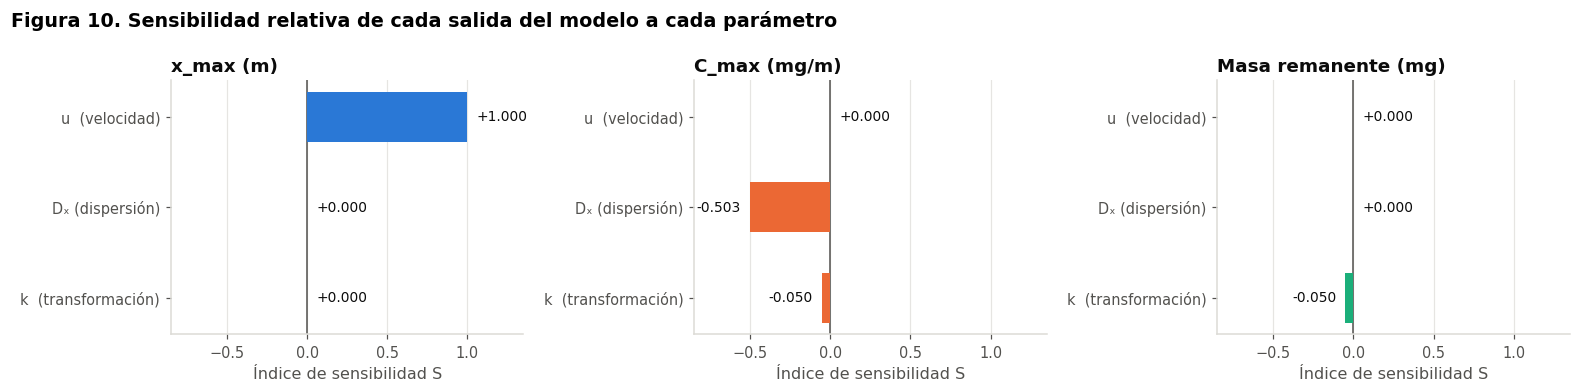

In [22]:
# ============================================================================
# ACTIVIDAD 9 — Gráfico tornado de sensibilidad
# ============================================================================
etiquetas_par = {"u": "u  (velocidad)", "Dx": "Dₓ (dispersión)", "k": "k  (transformación)"}
variables = list(base_out.keys())

fig, axes = plt.subplots(1, 3, figsize=(14.4, 3.6))
for ax, var, c in zip(axes, variables, SERIES):
    sub = sens[sens["Variable de salida"] == var].set_index("Parámetro").loc[["u", "Dx", "k"]]
    y = np.arange(len(sub))[::-1]
    ax.barh(y, sub["Índice S (elasticidad)"], color=c, height=0.55, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels([etiquetas_par[p] for p in sub.index])
    ax.axvline(0, color=COL["ink2"], linewidth=1.0)
    for yi, v in zip(y, sub["Índice S (elasticidad)"]):
        ax.annotate(f"{v:+.3f}", xy=(v, yi), xytext=(6 if v >= 0 else -6, 0),
                    textcoords="offset points", va="center",
                    ha="left" if v >= 0 else "right", fontsize=9, color=COL["ink"])
    ax.set_title(var); ax.set_xlabel("Índice de sensibilidad S")
    ax.set_xlim(-0.85, 1.35); ax.grid(axis="y", visible=False)

fig.suptitle("Figura 10. Sensibilidad relativa de cada salida del modelo a cada parámetro",
             fontsize=12.5, fontweight="bold", x=0.005, ha="left")
fig.tight_layout()
guardar(fig, "fig10_tornado_sensibilidad"); plt.show()

### 9.5 Respuestas a las preguntas 40 a 44

**40. ¿Cuál de los parámetros modifica principalmente la velocidad de desplazamiento?**  
La **velocidad media $u$**, mediante $x_{\max}=ut$. Es el único parámetro con elasticidad
$S_u^{x_{\max}}=+1{,}000$ (proporcionalidad directa perfecta): a 1 h, la nube está en 360 m,
900 m o 1800 m según $u$ sea 0,10, 0,25 o 0,50 m/s. Ni $D_x$ ni $k$ afectan la posición
($S=0$).

**41. ¿Cuál modifica principalmente el grado de dispersión?**  
El **coeficiente de dispersión longitudinal $D_x$**, mediante $\sigma_x=\sqrt{2D_xt}$
(elasticidad $+0{,}5$ sobre el ancho y $-0{,}5$ sobre $C_{\max}$). Para $D_x=0$; 50; 100 y
200 m²/s se obtiene $\sigma_x=0$; 600; 848,5 y 1200 m.

**42. ¿Cuál modifica principalmente la pérdida de concentración?**  
La **constante $k$**, a través del factor $e^{-kt}$; es el único parámetro que reduce la masa
total del sistema. A 1 h las pérdidas son 0 %; 1,98 %; 4,88 % y 9,52 % para $k=0$; 0,02; 0,05 y
0,10 h⁻¹.

**43. ¿Existen interacciones entre los parámetros?**  
En la solución analítica, la respuesta *a tiempo fijo* es **separable**: cada parámetro actúa
sobre un factor distinto (posición, ancho, altura), de modo que las elasticidades cruzadas son
nulas. Sin embargo, **sí hay interacción cuando la variable de interés es espacial**: en la
formulación estacionaria $C(x)=C_0e^{-kx/u}$ lo que gobierna es el **cociente $k/u$**, y no cada
parámetro por separado —duplicar $u$ equivale a reducir $k$ a la mitad—. Igualmente, el número de
Péclet $Pe=uL/D_x$ decide si domina la advección o la dispersión, y el número de Damköhler
$Da=kL/u$ decide si el contaminante alcanza a degradarse dentro del tramo. Las interacciones,
por tanto, aparecen en cuanto se pregunta *cuánto llega a un punto dado*.

**44. ¿Cuál de los parámetros produce la mayor sensibilidad?**  
Depende del indicador (Tabla 9.5 y Figura 10):

| Variable de salida | Parámetro más sensible | $|S|$ |
|---|---|---|
| Posición del máximo $x_{\max}$ | $u$ | 1,000 |
| Concentración pico $C_{\max}$ | $D_x$ | 0,500 |
| Masa remanente | $k$ | 0,050 |

Para $C_{\max}$, $D_x$ es diez veces más influyente que $k$ ($|S|=0{,}5$ frente a $0{,}05$) en
este horizonte de 1 h; pero $|S_k| = kt$ **crece con el tiempo**, de modo que en un recorrido
largo (varios $t_{1/2}$) la transformación pasa a dominar la magnitud de la concentración. No
existe un parámetro "más sensible" universal: la jerarquía depende de la salida evaluada y de la
escala temporal del problema.

---
# ACTIVIDAD 10. INTERPRETACIÓN DE PARÁMETROS EN UN SISTEMA REAL

### 10.1 Objetivo
Relacionar los parámetros matemáticos del modelo con variables obtenibles de un sistema
ambiental real, y clasificarlos según la forma de obtención (preguntas 45 a 48).

In [23]:
# ============================================================================
# ACTIVIDAD 10 — Tabla de parámetros y su obtención en campo
# ============================================================================
param = pd.DataFrame([
    ["u",  "Velocidad media de desplazamiento del agua y del contaminante",
     "Aforo (caudal / área de la sección) o medición directa con correntómetro o ADCP",
     "Sí", "Sí", "Rara vez", "Poco recomendable",
     "0,25 m/s (valor de la práctica)"],
    ["D",  "Coeficiente de difusión molecular; transporte por agitación térmica de las moléculas",
     "Literatura, ensayos de laboratorio o correlaciones según el contaminante y la temperatura",
     "No", "Sí", "No", "Sí",
     "1×10⁻⁹ m²/s"],
    ["Dx", "Coeficiente de dispersión longitudinal; ensanchamiento por advección diferencial y turbulencia",
     "Ensayos con trazadores (método de momentos), fórmulas empíricas y calibración del modelo",
     "Indirectamente", "Sí", "Sí", "Con precaución",
     "≈51 m²/s (Actividad 3); 50 m²/s adoptado"],
    ["k",  "Constante de transformación de primer orden (degradación biótica/abiótica)",
     "Ensayos de degradación, series temporales de concentración o calibración",
     "Indirectamente", "Sí", "Sí", "Como valor inicial",
     "0,05 h⁻¹ / 0,06931 d⁻¹"],
    ["C₀", "Concentración inicial del contaminante en la fuente",
     "Muestreo y análisis fisicoquímico en el punto de vertido",
     "Sí", "No", "No", "No",
     "10 y 20 mg/L"],
    ["M",  "Masa total de contaminante liberada al sistema",
     "Volumen o caudal de la descarga × concentración del efluente",
     "Sí", "Sí", "A veces", "No",
     "1000 mg"],
], columns=["Parámetro", "Significado físico", "Método de obtención",
            "45. ¿Medible en campo?", "46. ¿Estimable?", "47. ¿Requiere calibración?",
            "48. ¿De literatura?", "Valor usado en la práctica"])
tabla(param, "act10_parametros", "Tabla 10.1 — Parámetros del modelo y su obtención en un sistema real")

clas = pd.DataFrame([
    ["45. Medibles directamente en campo", "u, C₀, M"],
    ["46. Estimables (ensayos o correlaciones)", "D, Dx, k"],
    ["47. Requieren calibración", "Dx principalmente; k con frecuencia"],
    ["48. Obtenibles de literatura", "D (fiable); k y Dx solo como valores iniciales"],
], columns=["Categoría", "Parámetros"])
tabla(clas, "act10_clasificacion", "Tabla 10.2 — Clasificación de los parámetros según su obtención")

**Tabla 10.1 — Parámetros del modelo y su obtención en un sistema real**  ·  `resultados/act10_parametros.csv`

Parámetro,Significado físico,Método de obtención,45. ¿Medible en campo?,46. ¿Estimable?,47. ¿Requiere calibración?,48. ¿De literatura?,Valor usado en la práctica
u,Velocidad media de desplazamiento del agua y del contaminante,Aforo (caudal / área de la sección) o medición directa con correntómetro o ADCP,Sí,Sí,Rara vez,Poco recomendable,"0,25 m/s (valor de la práctica)"
D,Coeficiente de difusión molecular; transporte por agitación térmica de las moléculas,"Literatura, ensayos de laboratorio o correlaciones según el contaminante y la temperatura",No,Sí,No,Sí,1×10⁻⁹ m²/s
Dx,Coeficiente de dispersión longitudinal; ensanchamiento por advección diferencial y turbulencia,"Ensayos con trazadores (método de momentos), fórmulas empíricas y calibración del modelo",Indirectamente,Sí,Sí,Con precaución,≈51 m²/s (Actividad 3); 50 m²/s adoptado
k,Constante de transformación de primer orden (degradación biótica/abiótica),"Ensayos de degradación, series temporales de concentración o calibración",Indirectamente,Sí,Sí,Como valor inicial,"0,05 h⁻¹ / 0,06931 d⁻¹"
C₀,Concentración inicial del contaminante en la fuente,Muestreo y análisis fisicoquímico en el punto de vertido,Sí,No,No,No,10 y 20 mg/L
M,Masa total de contaminante liberada al sistema,Volumen o caudal de la descarga × concentración del efluente,Sí,Sí,A veces,No,1000 mg


**Tabla 10.2 — Clasificación de los parámetros según su obtención**  ·  `resultados/act10_clasificacion.csv`

Categoría,Parámetros
45. Medibles directamente en campo,"u, C₀, M"
46. Estimables (ensayos o correlaciones),"D, Dx, k"
47. Requieren calibración,Dx principalmente; k con frecuencia
48. Obtenibles de literatura,D (fiable); k y Dx solo como valores iniciales


,Categoría,Parámetros
0,45. Medibles directamente en campo,"u, C₀, M"
1,46. Estimables (ensayos o correlaciones),"D, Dx, k"
2,47. Requieren calibración,Dx principalmente; k con frecuencia
3,48. Obtenibles de literatura,D (fiable); k y Dx solo como valores iniciales


---
# INSUMOS NUMÉRICOS PARA LA ACTIVIDAD 11 (DISCUSIÓN)

La Actividad 11 es de discusión conceptual (preguntas 49 a 55). Las celdas siguientes generan
**los números de respaldo** que permiten argumentarla cuantitativamente: comparación
difusión/dispersión, números adimensionales de Péclet y Damköhler, y escalas de tiempo
características de cada proceso.

In [24]:
# ============================================================================
# INSUMOS PARA LA DISCUSIÓN — Números adimensionales y escalas de tiempo
# ============================================================================
u_d, Dx_d, k_d, D_d = 0.25, 50.0, 0.05, 1e-9      # m/s, m²/s, 1/h, m²/s
k_s = k_d/3600.0                                   # 1/s

filas = []
for L in [100.0, 1000.0, 5000.0, 10000.0]:
    t_adv  = L/u_d                                 # s, tiempo de viaje
    t_disp = L**2/(2*Dx_d)                         # s, tiempo de dispersión sobre la escala L
    t_reac = 1.0/k_s                               # s, tiempo característico de reacción
    Pe     = u_d*L/Dx_d                            # Péclet: advección / dispersión
    Da     = k_s*L/u_d                             # Damköhler: reacción / advección
    filas.append([L, L/1000, t_adv/3600, t_disp/3600, t_reac/3600, Pe, Da,
                  100*np.exp(-Da), "Advección" if Pe > 1 else "Dispersión"])
adim = pd.DataFrame(filas, columns=[
    "L (m)", "L (km)", "t_advección (h)", "t_dispersión (h)", "t_reacción (h)",
    "Péclet Pe = uL/Dx", "Damköhler Da = kL/u", "C/C₀ al final del tramo (%)", "Proceso dominante"])
tabla(adim, "disc_numeros_adimensionales",
      "Tabla 11.1 — Números adimensionales y escalas de tiempo por longitud de tramo")

comp2 = pd.DataFrame([
    ["Difusión molecular D", D_d, sigma_x(D_d, 3600), sigma_x(D_d, 86400)],
    ["Dispersión longitudinal Dx", Dx_d, sigma_x(Dx_d, 3600), sigma_x(Dx_d, 86400)],
], columns=["Mecanismo", "Coeficiente (m²/s)", "σ tras 1 h (m)", "σ tras 24 h (m)"])
comp2["Razón σ frente a D"] = comp2["σ tras 1 h (m)"]/comp2["σ tras 1 h (m)"].iloc[0]
comp2["Razón frente a D"] = comp2["Coeficiente (m²/s)"]/D_d
tabla(comp2, "disc_difusion_vs_dispersion",
      "Tabla 11.2 — Magnitud comparada de la difusión molecular y la dispersión longitudinal")

print(f"Razón Dx/D = {Dx_d/D_d:.2e}")
print(f"σ a 1 h por difusión molecular: {sigma_x(D_d,3600)*1000:.2f} mm")
print(f"σ a 1 h por dispersión:         {sigma_x(Dx_d,3600):.0f} m  ({sigma_x(Dx_d,3600)/sigma_x(D_d,3600):.2e} veces mayor)")
print("\nProcesos de un río real NO incluidos en el modelo (pregunta 52):")
for p in ["Variación espacial y temporal de u (crecidas, estiaje, remansos, rápidos)",
          "Zonas muertas y almacenamiento transitorio (transient storage)",
          "Intercambio con sedimentos, adsorción/desorción y resuspensión",
          "Volatilización e intercambio con la atmósfera",
          "Sedimentación de material particulado",
          "Cinéticas no lineales, dependientes de temperatura, pH, OD o luz",
          "Aportes laterales: afluentes, escorrentía, vertidos difusos",
          "Reaireación y acoplamiento OD–DBO",
          "Dispersión transversal y vertical (mezcla incompleta cerca del vertido)",
          "Retardo por reacciones de sorción (factor de retardo R)"]:
    print("  •", p)

**Tabla 11.1 — Números adimensionales y escalas de tiempo por longitud de tramo**  ·  `resultados/disc_numeros_adimensionales.csv`

L (m),L (km),t_advección (h),t_dispersión (h),t_reacción (h),Péclet Pe = uL/Dx,Damköhler Da = kL/u,C/C₀ al final del tramo (%),Proceso dominante
100.0000,0.1000,0.1111,0.0278,20.0000,0.5000,0.0056,99.4460,Dispersión
1000.0000,1.0000,1.1111,2.7778,20.0000,5.0000,0.0556,94.5959,Advección
5000.0000,5.0000,5.5556,69.4444,20.0000,25.0000,0.2778,75.7465,Advección
10000.0000,10.0000,11.1111,277.7778,20.0000,50.0000,0.5556,57.3753,Advección


**Tabla 11.2 — Magnitud comparada de la difusión molecular y la dispersión longitudinal**  ·  `resultados/disc_difusion_vs_dispersion.csv`

Mecanismo,Coeficiente (m²/s),σ tras 1 h (m),σ tras 24 h (m),Razón σ frente a D,Razón frente a D
Difusión molecular D,0.0000,0.0027,0.0131,1.0000,1.0000
Dispersión longitudinal Dx,50.0000,600.0000,2939.3877,223606.7977,50000000000.0000


Razón Dx/D = 5.00e+10
σ a 1 h por difusión molecular: 2.68 mm
σ a 1 h por dispersión:         600 m  (2.24e+05 veces mayor)

Procesos de un río real NO incluidos en el modelo (pregunta 52):
  • Variación espacial y temporal de u (crecidas, estiaje, remansos, rápidos)
  • Zonas muertas y almacenamiento transitorio (transient storage)
  • Intercambio con sedimentos, adsorción/desorción y resuspensión
  • Volatilización e intercambio con la atmósfera
  • Sedimentación de material particulado
  • Cinéticas no lineales, dependientes de temperatura, pH, OD o luz
  • Aportes laterales: afluentes, escorrentía, vertidos difusos
  • Reaireación y acoplamiento OD–DBO
  • Dispersión transversal y vertical (mezcla incompleta cerca del vertido)
  • Retardo por reacciones de sorción (factor de retardo R)


### Guía de respuesta para las preguntas 49 a 55 *(respaldo cuantitativo)*

- **49. No existe un $D_x$ universal** porque es un coeficiente *efectivo* que depende de la
  hidráulica y la geometría de cada cauce: $D_x \sim u^2B^2/(h\,u^*)$ según Fischer, de modo que
  ancho, profundidad, pendiente, rugosidad, sinuosidad y caudal lo modifican. En la propia
  Actividad 3, con un mismo río y un mismo trazador, $D_x$ varió entre 44,4 y 59,3 m²/s
  (CV ≈ 14,6 %) solo por el momento del muestreo.
- **50.** Ver Tabla 11.2: $D_x/D \approx 5\times10^{10}$. La difusión molecular mueve milímetros
  por hora; la dispersión, cientos de metros.
- **51. Supuestos que permiten la solución analítica:** flujo 1D, permanente y uniforme; $u$,
  $D_x$ y $k$ constantes; sección transversal constante con mezcla completa; medio infinito sin
  fronteras; fuente instantánea puntual (o continua constante); cinética lineal de primer orden;
  ausencia de aportes laterales y de retardo por sorción.
- **52.** Lista impresa en la celda anterior.
- **53. Para llevarlo a un río real** se requieren: batimetría y geometría por tramos, curva de
  gasto y series de caudal, campañas de trazadores en varias secciones, temperatura y
  fisicoquímica del agua, inventario de fuentes puntuales y difusas, ensayos de degradación, y
  datos independientes de calibración y validación. El paso siguiente sería una solución
  numérica (diferencias o volúmenes finitos) con parámetros variables por tramo.
- **54. Medido vs. calibrado:** un parámetro medido proviene de una observación directa con su
  propia incertidumbre instrumental y es independiente del modelo; un parámetro calibrado se
  *ajusta* para que la simulación reproduzca observaciones, por lo que absorbe además todos los
  errores estructurales del modelo y **solo es válido en el rango de condiciones calibrado**.
- **55. Importancia del análisis de sensibilidad:** identifica en qué parámetros conviene
  invertir esfuerzo de medición (aquí, $u$ para la posición y $D_x$ para el pico), acota la
  incertidumbre de la predicción, evita la sobreparametrización y orienta la calibración. La
  Tabla 9.5 muestra que un error del 10 % en $u$ desplaza el pico un 10 %, mientras que el mismo
  error en $k$ modifica la concentración solo un 0,5 % a 1 h.

---
# 13. SÍNTESIS CONCEPTUAL Y 14. SECUENCIA DENTRO DEL CURSO

$$\frac{\partial C}{\partial t} + u\frac{\partial C}{\partial x}
= D_x\frac{\partial^2 C}{\partial x^2} - kC$$

**Advección → desplazamiento · Difusión/Dispersión → ensanchamiento · Transformación → pérdida**

Las figuras siguientes sintetizan gráficamente ambos apartados.

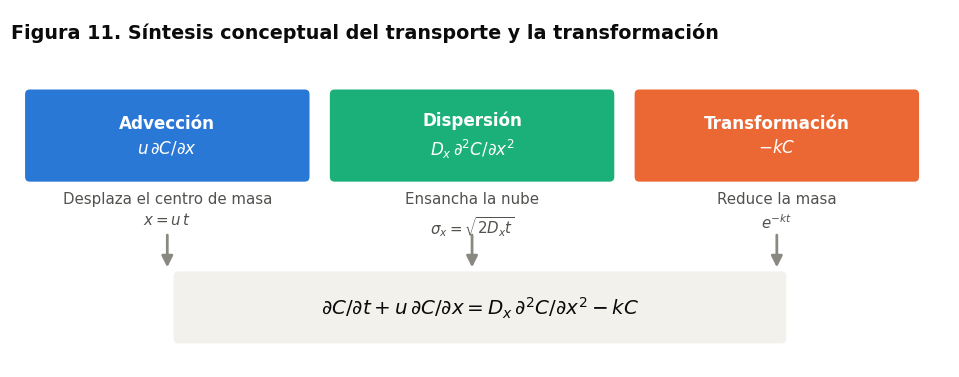

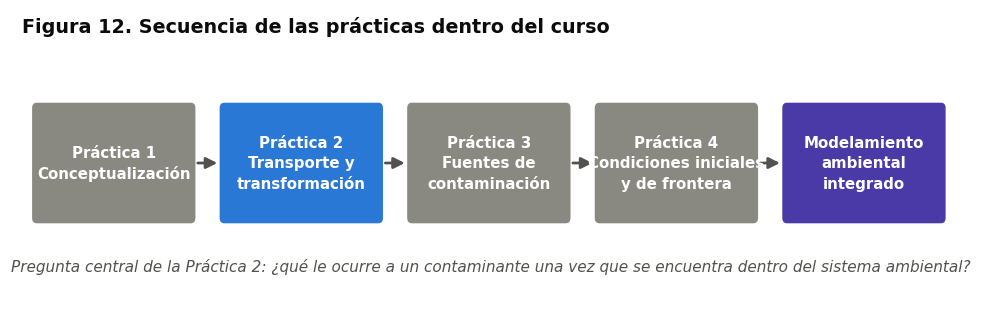

In [25]:
# ============================================================================
# 13 y 14 — Diagramas de síntesis conceptual y de secuencia del curso
# ============================================================================
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def caja(ax, x, y, w, h, texto, color, texto_color="white", fs=10.5, negrita=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.06",
                                linewidth=0, facecolor=color))
    ax.text(x+w/2, y+h/2, texto, ha="center", va="center", color=texto_color,
            fontsize=fs, fontweight="bold" if negrita else "normal", linespacing=1.45)

def flecha(ax, p0, p1, color):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=15,
                                 linewidth=1.8, color=color, shrinkA=0, shrinkB=0))

# --- Figura 11: síntesis conceptual ---
fig, ax = plt.subplots(figsize=(11.0, 4.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 4.4); ax.axis("off"); ax.grid(False)

ax.text(0.0, 4.05, "Figura 11. Síntesis conceptual del transporte y la transformación",
        fontsize=12.5, fontweight="bold", color=COL["ink"], ha="left")

procesos = [
    (0.2, "Advección\n$u\\,\\partial C/\\partial x$", "Desplaza el centro de masa\n$x = u\\,t$", COL["s1"]),
    (4.1, "Dispersión\n$D_x\\,\\partial^2 C/\\partial x^2$", "Ensancha la nube\n$\\sigma_x=\\sqrt{2D_xt}$", COL["s3"]),
    (8.0, "Transformación\n$-kC$", "Reduce la masa\n$e^{-kt}$", COL["s2"]),
]
for x0, titulo, detalle, c in procesos:
    caja(ax, x0, 2.30, 3.6, 1.10, titulo, c, fs=11)
    ax.text(x0+1.8, 2.16, detalle, ha="center", va="top", fontsize=9.8, color=COL["ink2"],
            linespacing=1.4)
    flecha(ax, (x0+1.8, 1.62), (x0+1.8, 1.22), COL["muted"])

caja(ax, 2.1, 0.30, 7.8, 0.85,
     "$\\partial C/\\partial t + u\\,\\partial C/\\partial x = D_x\\,\\partial^2C/\\partial x^2 - kC$",
     "#f2f1ec", texto_color=COL["ink"], fs=13)

guardar(fig, "fig11_sintesis_conceptual"); plt.show()

# --- Figura 12: secuencia del curso ---
fig, ax = plt.subplots(figsize=(11.0, 3.4))
ax.set_xlim(0, 12); ax.set_ylim(0, 3.2); ax.axis("off"); ax.grid(False)
ax.text(0.0, 2.95, "Figura 12. Secuencia de las prácticas dentro del curso",
        fontsize=12.5, fontweight="bold", color=COL["ink"], ha="left")

etapas = [
    ("Práctica 1\nConceptualización", COL["muted"]),
    ("Práctica 2\nTransporte y\ntransformación", COL["s1"]),
    ("Práctica 3\nFuentes de\ncontaminación", COL["muted"]),
    ("Práctica 4\nCondiciones iniciales\ny de frontera", COL["muted"]),
    ("Modelamiento\nambiental\nintegrado", COL["s4"]),
]
w, gap = 2.05, 0.35
for i, (txt, c) in enumerate(etapas):
    x0 = 0.15 + i*(w+gap)
    caja(ax, x0, 0.85, w, 1.30, txt, c, fs=9.8)
    if i < len(etapas)-1:
        flecha(ax, (x0+w+0.05, 1.50), (x0+w+gap-0.05, 1.50), COL["ink2"])

ax.text(6.0, 0.30, "Pregunta central de la Práctica 2: ¿qué le ocurre a un contaminante una vez "
        "que se encuentra dentro del sistema ambiental?",
        ha="center", fontsize=10, color=COL["ink2"], style="italic")
guardar(fig, "fig12_secuencia_curso"); plt.show()

---
# CONCLUSIONES (requisito 65 de la Actividad 12)

1. **La advección solo traslada.** Sobre la trayectoria de la parcela $dC/dt=0$, por lo que en
   advección pura la concentración se mantiene en $C_0=10$ mg/L cualquiera sea la distancia; con
   $u=0{,}25$ m/s se recorren 450 m en 30 min, 1800 m en 2 h y se necesitan 20 000 s (5,56 h)
   para 5 km. La pendiente de $x$ vs. $t$ *es* la velocidad del flujo.

2. **La difusión y la dispersión ensanchan sin desplazar y conservan la masa.** El pico decae
   como $t^{-1/2}$ y el ancho crece como $t^{1/2}$; la integración numérica devolvió 1000 mg en
   todos los tiempos y para todos los $D_x$, confirmando la conservación de la masa.

3. **La escala de la difusión molecular es irrelevante en un río.** Con $D=10^{-9}$ m²/s la nube
   crece milímetros ($\sigma$ = 2,68 mm a 1 h), mientras que con $D_x=50$ m²/s alcanza 600 m en
   el mismo tiempo: una razón $D_x/D\approx5\times10^{10}$.

4. **$D_x$ es un coeficiente efectivo, no una constante del contaminante.** Los datos del
   trazador dieron 44,44; 50,00 y 59,26 m²/s (media 51,23; CV 14,6 %), con tendencia creciente,
   señal de que la nube aún no ha alcanzado la fase fickiana.

5. **La transformación de primer orden reduce la masa de forma exponencial y su vida media es
   independiente de $C_0$:** $t_{1/2}=13{,}86$ h para $k=0{,}05$ h⁻¹ y $t_{1/2}=10$ d para el
   $k=0{,}06931$ d⁻¹ estimado en la Actividad 5.

6. **Al combinar advección y reacción lo que gobierna es el cociente $k/u$.** $C(x)=C_0e^{-kx/u}$
   da 9,46; 7,57 y 5,74 mg/L a 1, 5 y 10 km: una mayor velocidad entrega **más** concentración
   aguas abajo porque acorta el tiempo disponible para degradarse.

7. **En el modelo integrado los tres procesos son separables a tiempo fijo:** $u$ fija la
   posición (900 m), $D_x$ el ancho ($\sigma=600$ m) y la altura (0,6649 mg/m), y $k$ escala toda
   la curva por $e^{-kt}=0{,}9512$, con una pérdida uniforme del 4,88 % (48,8 mg) sin alterar ni
   el centro ni el ancho.

8. **El análisis de sensibilidad jerarquiza el esfuerzo de medición.** Las elasticidades son
   $S_u^{x_{\max}}=1$, $S_{D_x}^{C_{\max}}=-0{,}5$ y $S_k^{C_{\max}}=-kt=-0{,}05$: a 1 h, $D_x$
   es diez veces más determinante que $k$ sobre el pico, pero $|S_k|$ crece con el tiempo, de modo
   que en tramos largos la transformación domina. No hay un parámetro más sensible universal.

9. **El modelo es una idealización útil pero limitada.** Supone flujo 1D uniforme, parámetros
   constantes, mezcla completa y cinética lineal; no representa zonas muertas, sedimentos,
   volatilización, aportes laterales ni variabilidad hidrológica. Su valor está en aislar y
   cuantificar el rol de cada mecanismo, que es la base para modelos numéricos más completos.

---
# EXPORTACIÓN FINAL DE RESULTADOS

La celda siguiente consolida **todas las tablas, valores clave y figuras** en el archivo
`resultados/RESUMEN_RESULTADOS.md`. Ese archivo contiene, en texto plano, todo lo necesario para
redactar el informe (Actividades 11, 12 y 14) sin volver a ejecutar el notebook.

In [26]:
# ============================================================================
# EXPORTACIÓN — Resumen completo en Markdown + índice de salidas
# ============================================================================
def df_a_markdown(df, dec=4):
    """Convierte un DataFrame a tabla Markdown (sin dependencias externas)."""
    def celda(v):
        if isinstance(v, (float, np.floating)):
            if np.isnan(v):   return "n/d"
            if np.isinf(v):   return "∞"
            if v != 0 and (abs(v) >= 1e6 or abs(v) < 1e-4):
                return f"{v:.3e}"
            return f"{v:,.{dec}f}".rstrip("0").rstrip(".") or "0"
        return str(v)
    cols = [str(c) for c in df.columns]
    out  = ["| " + " | ".join(cols) + " |",
            "|" + "|".join(["---"]*len(cols)) + "|"]
    for _, fila in df.iterrows():
        out.append("| " + " | ".join(celda(v) for v in fila.values) + " |")
    return "\n".join(out)

lineas = [
    "# RESUMEN DE RESULTADOS — Práctica N.° 2",
    "## Modelamiento del transporte y transformación de contaminantes",
    "",
    "Generado automáticamente por `Practica_2.ipynb`. Contiene todas las tablas de resultados,",
    "los valores numéricos clave y el índice de figuras de las Actividades 1 a 10.",
    "",
    "---",
    "",
    "## 1. Valores numéricos clave",
    "",
    "| Clave | Valor | Unidad | Descripción |",
    "|---|---|---|---|",
]
for clave, (valor, unidad, desc) in VALORES.items():
    v = f"{valor:,.5g}" if isinstance(valor, (int, float, np.floating)) else str(valor)
    lineas.append(f"| `{clave}` | {v} | {unidad} | {desc} |")

lineas += ["", "---", "", "## 2. Tablas de resultados", ""]
for nombre, (titulo, df) in TABLAS.items():
    lineas += [f"### {titulo}", f"*Archivo:* `resultados/{nombre}.csv`", "",
               df_a_markdown(df), ""]

lineas += ["---", "", "## 3. Índice de figuras", "",
           "| Figura | Archivo |", "|---|---|"]
titulos_fig = {
    "fig01_adveccion_x_vs_t": "Figura 1. Advección pura: distancia recorrida frente al tiempo",
    "fig02_difusion_molecular": "Figura 2. Difusión molecular de un pulso instantáneo",
    "fig03_estimacion_Dx": "Figura 3. Estimación del coeficiente de dispersión longitudinal",
    "fig04_primer_orden": "Figura 4. Transformación de primer orden",
    "fig05_estimacion_k": "Figura 5. Estimación de k y proyección del decaimiento",
    "fig06_adveccion_transformacion": "Figura 6. Advección + transformación C(x)=C0·e^(−kx/u)",
    "fig07_adveccion_dispersion": "Figura 7. Advección + dispersión: efecto de Dx",
    "fig08_modelo_integrado": "Figura 8. Modelo integrado: concentración frente a distancia",
    "fig09_sensibilidad_paneles": "Figura 9. Análisis de sensibilidad: efecto individual de u, Dx y k",
    "fig10_tornado_sensibilidad": "Figura 10. Sensibilidad relativa de cada salida a cada parámetro",
    "fig11_sintesis_conceptual": "Figura 11. Síntesis conceptual del transporte y la transformación",
    "fig12_secuencia_curso": "Figura 12. Secuencia de las prácticas dentro del curso",
}
for nombre, ruta in FIGURAS.items():
    lineas.append(f"| {titulos_fig.get(nombre, nombre)} | `{ruta}` |")

lineas += ["", "---", "",
           "## 4. Ecuaciones utilizadas", "",
           "| Proceso | Ecuación de gobierno | Solución empleada |",
           "|---|---|---|",
           "| Advección | ∂C/∂t + u ∂C/∂x = 0 | x = u·t ; C = C₀ |",
           "| Difusión | ∂C/∂t = D ∂²C/∂x² | C = M/√(4πDt)·exp(−x²/4Dt) |",
           "| Dispersión (estimación) | σₓ² = 2Dₓt | Dₓ = σₓ²/(2t) |",
           "| Transformación | dC/dt = −kC | C = C₀e^(−kt) ; t½ = ln2/k |",
           "| Advección + transformación | ∂C/∂t + u ∂C/∂x = −kC | C(x) = C₀e^(−kx/u) |",
           "| Advección + dispersión | ∂C/∂t + u ∂C/∂x = Dₓ ∂²C/∂x² | C = M/√(4πDₓt)·exp(−(x−ut)²/4Dₓt) |",
           "| Modelo integrado | ∂C/∂t + u ∂C/∂x = Dₓ ∂²C/∂x² − kC | el anterior × e^(−kt) |",
           ""]

texto_md = "\n".join(lineas)
ruta_md = RES_DIR / "RESUMEN_RESULTADOS.md"
ruta_md.write_text(texto_md, encoding="utf-8")

print(f"✔ Resumen exportado: {ruta_md.resolve()}  ({len(texto_md):,} caracteres)")
print(f"✔ {len(TABLAS)} tablas exportadas a CSV en {RES_DIR.resolve()}")
print(f"✔ {len(FIGURAS)} figuras exportadas a PNG en {FIG_DIR.resolve()}")
print(f"✔ {len(VALORES)} valores clave registrados\n")
print("Tablas generadas:")
for nombre, (titulo, df) in TABLAS.items():
    print(f"  - {nombre:<32} {df.shape[0]:>2}×{df.shape[1]:<2}  {titulo}")
print("\nFiguras generadas:")
for nombre, ruta in FIGURAS.items():
    print(f"  - {ruta}")

✔ Resumen exportado: /home/jeremy/Documentos/modelamiento/resultados/RESUMEN_RESULTADOS.md  (20,118 caracteres)
✔ 29 tablas exportadas a CSV en /home/jeremy/Documentos/modelamiento/resultados
✔ 12 figuras exportadas a PNG en /home/jeremy/Documentos/modelamiento/figuras
✔ 47 valores clave registrados

Tablas generadas:
  - act1_ejercicio                    5×4   Tabla 1.1 — Resultados del ejercicio de advección (u = 0.25 m/s)
  - act1_x_vs_t                      11×5   Tabla 1.2 — Distancia recorrida x = u·t para tres velocidades (0–10 h)
  - act2_difusion_resumen             3×6   Tabla 2.1 — Difusión molecular: pico y ensanchamiento de la nube
  - act2_perfil_C                     7×4   Tabla 2.2 — Distribución espacial C(x) a 1 h, 6 h y 24 h
  - act2_duplicar_D                   2×6   Tabla 2.3 — Efecto de duplicar D a t = 24 h
  - act2_difusion_vs_dispersion       2×4   Tabla 2.4 — Tiempo necesario para alcanzar σ = 100 m según el mecanismo
  - act3_estimacion_Dx                3×6 

In [27]:
# ============================================================================
# VERIFICACIÓN FINAL — Todos los resultados numéricos de la práctica
# ============================================================================
print("="*78)
print("RESULTADOS PRINCIPALES DE LA PRÁCTICA N.° 2".center(78))
print("="*78)

bloques = [
    ("ACT. 1 — ADVECCIÓN (u = 0,25 m/s; C₀ = 10 mg/L)", [
        ("x a los 30 min", f"{VALORES['A1_x_30min'][0]:.0f} m"),
        ("x a las 2 h", f"{VALORES['A1_x_2h'][0]:.0f} m"),
        ("t para 5 km", f"{VALORES['A1_t_5km_s'][0]:.0f} s = {VALORES['A1_t_5km_h'][0]:.2f} h"),
        ("C tras 5 km", f"{VALORES['A1_C_5km'][0]:.1f} mg/L (invariante)"),
    ]),
    ("ACT. 2 — DIFUSIÓN MOLECULAR (M = 1000 mg; D = 1e-9 m²/s)", [
        ("σ a 1 h / 6 h / 24 h", f"{VALORES['A2_sigma_1h'][0]:.2f} / {VALORES['A2_sigma_6h'][0]:.2f} / {VALORES['A2_sigma_24h'][0]:.2f} mm"),
        ("C_max a 1 h / 24 h", f"{VALORES['A2_Cmax_1h'][0]:.3e} / {VALORES['A2_Cmax_24h'][0]:.3e} mg/m"),
        ("Razón Dx/D", f"{VALORES['A2_razon_Dx_D'][0]:.2e}"),
    ]),
    ("ACT. 3 — COEFICIENTE DE DISPERSIÓN", [
        ("Dx (1800 / 3600 / 5400 s)", f"{VALORES['A3_Dx_1800'][0]:.2f} / {VALORES['A3_Dx_3600'][0]:.2f} / {VALORES['A3_Dx_5400'][0]:.2f} m²/s"),
        ("Dx medio", f"{VALORES['A3_Dx_medio'][0]:.2f} m²/s (CV = {VALORES['A3_CV_Dx'][0]:.1f} %)"),
        ("Dx por regresión", f"{VALORES['A3_Dx_regresion'][0]:.2f} m²/s"),
    ]),
    ("ACT. 4 — PRIMER ORDEN (C₀ = 20 mg/L; k = 0,05 h⁻¹)", [
        ("C a 1 / 5 / 10 / 24 h", f"{VALORES['A4_C_1h'][0]:.2f} / {VALORES['A4_C_5h'][0]:.2f} / {VALORES['A4_C_10h'][0]:.2f} / {VALORES['A4_C_24h'][0]:.2f} mg/L"),
        ("Vida media", f"{VALORES['A4_t_medio'][0]:.2f} h"),
    ]),
    ("ACT. 5 — ESTIMACIÓN DE k (20 → 10 mg/L en 10 d)", [
        ("k", f"{VALORES['A5_k'][0]:.5f} d⁻¹"),
        ("Vida media", f"{VALORES['A5_t_medio'][0]:.2f} d"),
        ("C a 20 d / 30 d", f"{VALORES['A5_C_20d'][0]:.2f} / {VALORES['A5_C_30d'][0]:.2f} mg/L"),
    ]),
    ("ACT. 6 — ADVECCIÓN + TRANSFORMACIÓN (C₀ = 10 mg/L)", [
        ("u convertida", f"{VALORES['A6_u_kmh'][0]:.2f} km/h"),
        ("C a 1 / 5 / 10 km", f"{VALORES['A6_C_1km'][0]:.2f} / {VALORES['A6_C_5km'][0]:.2f} / {VALORES['A6_C_10km'][0]:.2f} mg/L"),
        ("Longitud característica u/k", f"{VALORES['A6_Lc'][0]:.2f} km"),
    ]),
    ("ACT. 7 — ADVECCIÓN + DISPERSIÓN (t = 1 h)", [
        ("Centro de la nube", f"{VALORES['A7_x_centro'][0]:.0f} m"),
        ("C_max (Dx = 50/100/200)", f"{VALORES['A7_Cmax_Dx50'][0]:.4f} / {VALORES['A7_Cmax_Dx100'][0]:.4f} / {VALORES['A7_Cmax_Dx200'][0]:.4f} mg/m"),
        ("σ (Dx = 50/100/200)", f"{VALORES['A7_sigma_Dx50'][0]:.1f} / {VALORES['A7_sigma_Dx100'][0]:.1f} / {VALORES['A7_sigma_Dx200'][0]:.1f} m"),
    ]),
    ("ACT. 8 — MODELO INTEGRADO (t = 1 h)", [
        ("x_max (A, B y C)", f"{VALORES['A8_xmax'][0]:.0f} m"),
        ("C_max escenario B", f"{VALORES['A8_Cmax_B'][0]:.4f} mg/m"),
        ("C_max escenario C", f"{VALORES['A8_Cmax_C'][0]:.4f} mg/m"),
        ("σ escenarios B y C", f"{VALORES['A8_sigma'][0]:.0f} m"),
        ("Pérdida por transformación", f"{VALORES['A8_perdida_pct'][0]:.2f} %"),
    ]),
    ("ACT. 9 — SENSIBILIDAD", [
        ("x_max (u = 0,10 / 0,25 / 0,50)", f"{VALORES['A9_xmax_u010'][0]:.0f} / {VALORES['A8_xmax'][0]:.0f} / {VALORES['A9_xmax_u050'][0]:.0f} m"),
        ("Elasticidad S_u sobre x_max", f"{matriz.set_index('Parámetro').loc['u','x_max (m)']:+.3f}"),
        ("Elasticidad S_Dx sobre C_max", f"{matriz.set_index('Parámetro').loc['Dx','C_max (mg/m)']:+.3f}"),
        ("Elasticidad S_k sobre C_max", f"{matriz.set_index('Parámetro').loc['k','C_max (mg/m)']:+.3f}"),
    ]),
]

for titulo, items in bloques:
    print(f"\n{titulo}")
    print("-"*78)
    for etiqueta, valor in items:
        print(f"  {etiqueta:<34} : {valor}")

print("\n" + "="*78)
print("Ejecución completa. Revise resultados/RESUMEN_RESULTADOS.md".center(78))
print("="*78)

                 RESULTADOS PRINCIPALES DE LA PRÁCTICA N.° 2                  

ACT. 1 — ADVECCIÓN (u = 0,25 m/s; C₀ = 10 mg/L)
------------------------------------------------------------------------------
  x a los 30 min                     : 450 m
  x a las 2 h                        : 1800 m
  t para 5 km                        : 20000 s = 5.56 h
  C tras 5 km                        : 10.0 mg/L (invariante)

ACT. 2 — DIFUSIÓN MOLECULAR (M = 1000 mg; D = 1e-9 m²/s)
------------------------------------------------------------------------------
  σ a 1 h / 6 h / 24 h               : 2.68 / 6.57 / 13.15 mm
  C_max a 1 h / 24 h                 : 1.487e+05 / 3.035e+04 mg/m
  Razón Dx/D                         : 5.00e+10

ACT. 3 — COEFICIENTE DE DISPERSIÓN
------------------------------------------------------------------------------
  Dx (1800 / 3600 / 5400 s)          : 44.44 / 50.00 / 59.26 m²/s
  Dx medio                           : 51.23 m²/s (CV = 14.6 %)
  Dx por regresión        